# Clasificación de sentimiento en reseñas de productos — Parte 1 (ML clásico)
## Modelo v3a: ensemble v1 + componente estructural + stacking NB-LR por bloques

**Curso Aprendizaje de Máquina 2026-20 · Universidad de los Andes**

**Integrantes:** _(completar)_

### Objetivo
Predecir el sentimiento global (`negativo`, `neutral`, `positivo`) de reseñas de productos en español usando **solo aprendizaje de máquina clásico**: representaciones de bolsa de palabras / TF-IDF / n-gramas, ingeniería de rasgos con reglas, expresiones regulares y léxicos, y clasificadores de **scikit-learn**. No usamos redes neuronales (tampoco `MLPClassifier`), embeddings preentrenados, transformers ni librerías de boosting externas.

### Resumen del proceso y resultados
Accuracy con validación cruzada estratificada de 5 folds sobre `train.csv`, con dos particiones de los folds: `random_state=42`, para el análisis, y `random_state=2024`. Las dos juntas sirven para elegir los pesos del ensemble y medir la robustez. Todas las cifras se recalculan al ejecutar este notebook.

| # | Representación / modelo | CV partición 42 | CV partición 2024 | Kaggle público |
|---|---|---|---|---|
| 0 | Línea base: TF-IDF de palabras (1-2 gramas) sobre el texto completo + regresión logística | 0.7408 | — | — |
| 1 | **Bloques de texto según el orden** (completo + desde el último conector adversativo + última oración) + regresión logística | 0.8951 | 0.8939 | — |
| 2 | Bloques + n-gramas de **caracteres** + regresión logística | 0.8981 | 0.8962 | — |
| 3 | Bloques + palabras y caracteres + SVM lineal calibrado | 0.8998 | 0.8998 | — |
| 4 | **Stacking**: una regresión logística por bloque (6 bloques) + meta-clasificador HistGradientBoosting | 0.9012 | 0.9004 | — |
| 5 | **Ensemble v1**: voto suave ponderado de 1–4 (modelo entregado antes) | anidada 0.9061 | anidada 0.9055 | **0.90111** |
| 6 | **Componente estructural**: parser de las plantillas → 59 rasgos firmados por polaridad → HistGradientBoosting | 0.9075 | 0.9096 | — |
| 7 | **Stacking NB-LR** (`stk_nb6_anc`): un NB-LR por bloque sobre 10 bloques (los 6 anteriores + 4 anclados en las opiniones) + meta HGB | 0.9112 | 0.9094 | — |
| 8 | **Ensemble v3a (este notebook)**: voto suave sobre los 6 componentes; quedan con peso > 0 *svc_pal_car 0.4, estructural 0.3, stk_nb6_anc 0.3* | anidada **0.9170** | anidada **0.9134** | por enviar |

*Componentes: accuracy out-of-fold (OOF). Ensembles: accuracy **anidada**, es decir, con la elección de los pesos validada en reseñas que no se usaron para elegirlos (secciones 8 y 12).*

**Ideas clave**
1. El error de la bolsa de palabras se concentra en las reseñas que **mezclan** elogios y quejas. Con un conector adversativo fuerte (*pero, aun así, aunque…*) la etiqueta sigue a la opinión que viene **después**. Vectorizar por separado cada segmento del texto (bloques) lleva la accuracy de 0.74 a ~0.90 sin salir de la bolsa de palabras.
2. Al estudiar cómo están construidas las reseñas encontramos **dos familias de opiniones**: (A) *aspecto + verbo copulativo + adjetivo* (*"la batería resultó excelente"*), donde en las reseñas mixtas que terminan en opinión **gana la última opinión** el 99.8 % de las veces, y (B) *frases hechas* (*"fue todo un acierto"*, *"no vale lo que cuesta"*), donde en las mixtas la etiqueta coincide con la última opinión solo el 51.4 %: es prácticamente **aleatoria**. Las mixtas B son el 17.0 % de `train` y ponen un techo de ~0.915–0.92 a cualquier modelo.
3. Dos componentes nuevos explotan la parte determinista: un **parser estructural** de las plantillas y un **stacking NB-LR** con bloques anclados en las opiniones. Con ellos la accuracy anidada pasa de 0.9061 a 0.9170 con la partición 42 (**+1.09 puntos**) y de 0.9055 a 0.9134 con la 2024 (**+0.79**). Casi toda la ganancia la aporta el componente estructural. El stacking NB-LR suma poco cuando ya está el estructural, pero hace al ensemble más robusto si el parser falla (sección 13). Como el parser se diseñó mirando `train`, estas cifras son una **cota optimista** (secciones 13 y 18).

**Archivos que genera:** `modelo_v3a.joblib` (modelo final entrenado con todo `train`) y `submission_v3a.csv` (predicciones de `eval.csv`). La ejecución completa tarda ~21 minutos con `N_JOBS = 3`.

## 1. Configuración
- **Dos particiones de la validación cruzada.** Todos los modelos se evalúan con la misma validación cruzada externa, `StratifiedKFold(5, shuffle=True, random_state=42)`. Sus probabilidades *out-of-fold* (OOF) son comparables reseña a reseña y se pueden combinar en el ensemble sin fuga de información. Para elegir los pesos del ensemble y medir la robustez repetimos todo con una segunda partición (`random_state=2024`, sección 12).
- **`N_JOBS = 3`** solo fija cuántos procesos trabajan a la vez: **cambia la velocidad, no los resultados**. Para que eso sea cierto fijamos también 4 hilos por proceso (`OMP_NUM_THREADS` y afines) antes de importar las librerías. HistGradientBoosting y las rutinas de álgebra lineal (BLAS) que usa el optimizador de la regresión logística suman en paralelo, y el orden de esas sumas depende del número de hilos; en casos límite eso cambia algún *split* o alguna predicción. Con los hilos fijos, ejecuciones repetidas dan exactamente las mismas cifras. En otra máquina (otra CPU u otras versiones de las librerías), los dos componentes de *stacking* pueden variar del orden de ±0.1–0.3 puntos (sección 12).
- `eval.csv` **no se lee hasta la sección 16**, después de entrenar y guardar el modelo final.

In [1]:
import os
# Hilos por proceso fijos ANTES de importar numpy / scikit-learn (resultados idénticos con cualquier N_JOBS)
for variable in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS'):
    os.environ[variable] = '4'

import re
import sys
import time
import unicodedata
import collections
import warnings
from math import comb

import numpy as np
import pandas as pd
import scipy.sparse as sp
import joblib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import sklearn
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin, clone
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import HistGradientBoostingClassifier, StackingClassifier, VotingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.width', 200)

T_INICIO = time.time()
DATA_DIR = 'data'
SEED = 42                    # partición principal de la validación cruzada
SEED_2 = 2024                # segunda partición: junto con la 42 elige los pesos del ensemble y mide la robustez
PARTICIONES = [SEED, SEED_2]
SEED_ANIDADO = 123           # partición de la validación anidada de los pesos del ensemble
SEMILLAS_ANIDADO = [123, 7, 99]   # semillas de la validación anidada en el análisis de robustez (sección 13)
N_JOBS = 3                   # procesos en paralelo: solo afecta la velocidad
CLASES = np.array(['negativo', 'neutral', 'positivo'])   # orden alfabético = orden de las columnas de predict_proba
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
RESUMEN = {}                 # cifras clave que se van calculando (se muestran juntas al final)

# Estilo de las gráficas (paleta sobria, texto en tinta neutra)
SUPERFICIE, TINTA, TINTA2, TENUE, REJILLA, EJE = '#fcfcfb', '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
AZUL, NARANJA, AQUA, GRIS = '#2a78d6', '#eb6834', '#1baf7a', '#c3c2b7'
RAMPA_AZUL = LinearSegmentedColormap.from_list('azul', ['#f4f8fd', '#cde2fb', '#86b6ef', '#3987e5', '#256abf', '#184f95', '#0d366b'])
plt.rcParams.update({
    'figure.facecolor': SUPERFICIE, 'axes.facecolor': SUPERFICIE, 'savefig.facecolor': SUPERFICIE,
    'axes.edgecolor': EJE, 'axes.labelcolor': TINTA2, 'xtick.color': TENUE, 'ytick.color': TINTA2,
    'text.color': TINTA, 'axes.spines.top': False, 'axes.spines.right': False,
    'grid.color': REJILLA, 'grid.linestyle': '-', 'grid.linewidth': 0.8,
    'axes.titlelocation': 'left', 'axes.titlesize': 12, 'font.size': 10,
    'font.family': ['Segoe UI', 'DejaVu Sans'],
})

print('Python', sys.version.split()[0], '| scikit-learn', sklearn.__version__, '| pandas', pd.__version__,
      '| numpy', np.__version__)

Python 3.13.11 | scikit-learn 1.8.0 | pandas 3.0.2 | numpy 2.4.4


## 2. Carga y exploración de los datos

In [2]:
train = pd.read_csv(f'{DATA_DIR}/train.csv')
X = train.text.values
y = train.label.values

print('train:', train.shape, '| nulos:', train.isna().sum().sum(), '| textos duplicados:', train.text.duplicated().sum())
print()
print(train.label.value_counts().to_frame('n').assign(proporcion=lambda d: (d.n / d.n.sum()).round(3)))

train: (12000, 3) | nulos: 0 | textos duplicados: 0

             n  proporcion
label                     
positivo  4212       0.351
negativo  4212       0.351
neutral   3576       0.298


In [3]:
tiene_tilde = lambda s: bool(re.search('[áéíóúñü]', s.lower()))
pd.Series({'longitud media (caracteres)': train.text.str.len().mean(),
           'oraciones por reseña': train.text.str.count(r'[.!?]').mean(),
           '% reseñas con tildes o ñ': 100 * train.text.map(tiene_tilde).mean()}).round(1).to_frame('train')

,train
longitud media (caracteres),281.4
oraciones por reseña,3.9
% reseñas con tildes o ñ,68.7


In [4]:
for etiqueta in CLASES:
    print(f'===== {etiqueta}')
    for t in train[train.label == etiqueta].text.sample(3, random_state=1):
        print('  -', t)

===== negativo
  - Les cuento como me fue con esta compra. Llego en unos cuatro dias a mi casa aqui en Guadalajara y la compre en color azul, que al final el color es igual al de las fotos. La uso casi todos los dias para salir a correr por las mananas antes del trabajo, y por cierto la autonomia se mantuvo redonda al final de cuentas, o sea aguanta lo que dice en la descripcion. Lei las instrucciones y segun tiene sellado para sumergirla, pero la resistencia al agua me resulto ser defectuosa con el tiempo.
  - Le puse tres pilas AAA comunes y arrancó sin problema, lo compré hace unos meses para llevar de acá para allá. La verdad, la batería se mantuvo buenísima después de tanto trajín, eso me gustó. Eso sí, la portabilidad se ve floja en mi experiencia, no la puedo mover de un lado a otro con la facilidad que yo pensaba.
  - Me animo a comentar porque la pedí hace un par de semanas por internet y llegó en tres días. La tapa no vale lo que cuesta, la verdad. Por otro lado, el manual de

**Observaciones**
- Las clases están casi balanceadas (35 % negativo, 30 % neutral, 35 % positivo): la accuracy es una métrica adecuada y no hace falta reponderar clases.
- **≈31 % de las reseñas están escritas sin tildes** (*"llego"*, *"dia"*, *"diseno"*) y hay **errores de tipeo** (*"lleego"*, *"epsectacular"*). Lo tendremos en cuenta en el preprocesamiento.
- Las reseñas **neutrales** solo contienen hechos (envío, peso, garantía, pilas). Las positivas y negativas suelen mezclar **una opinión a favor y otra en contra**, unidas por conectores (*"Aun así"*, *"Eso sí"*, *"Por otro lado"*). Ahí está la dificultad del problema.
- Los textos tienen aspecto **sintético**: frases de relleno que se repiten (envío, peso, garantía) más una a tres cláusulas de opinión construidas con un repertorio limitado de expresiones. Lo aprovecharemos en la sección 9.

## 3. Preprocesamiento
- **Minúsculas y eliminación de tildes** (normalización Unicode NFKD): unifica *"llegó"* y *"llego"*, que en los datos aparecen indistintamente.
- **No eliminamos stopwords**: palabras como *"pero"*, *"no"*, *"aunque"* o *"aun así"* son justamente las que determinan el sentimiento global (conectores y negaciones).
- **No aplicamos stemming ni lematización**: en su lugar usamos n-gramas de caracteres, que capturan la morfología (*"decepcionó"/"decepcionante"*) y son robustos a los errores de tipeo. (En la sección 14 se resumen las variantes de preprocesamiento que probamos y no mejoraron.)

In [5]:
def normalizar(texto):
    # Minúsculas y sin tildes: 'Llegó RÁPIDO' -> 'llego rapido'
    texto = unicodedata.normalize('NFKD', str(texto).lower())
    return ''.join(c for c in texto if not unicodedata.combining(c))

print(normalizar('La batería es excelente, pero la cámara resultó DECEPCIONANTE.'))

la bateria es excelente, pero la camara resulto decepcionante.


## 4. Línea base: bolsa de palabras sobre el texto completo
TF-IDF de unigramas y bigramas sobre la reseña completa + regresión logística. Usamos `cross_val_predict` para obtener predicciones *out-of-fold* de todo `train` y analizar los errores.

In [6]:
linea_base = Pipeline([
    ('tfidf', TfidfVectorizer(preprocessor=normalizar, ngram_range=(1, 2), sublinear_tf=True, min_df=2)),
    ('clf', LogisticRegression(C=10, max_iter=5000)),
])
P_base = cross_val_predict(linea_base, X, y, cv=CV, method='predict_proba', n_jobs=N_JOBS)
pred_base = CLASES[P_base.argmax(1)]
RESUMEN['acc_linea_base'] = accuracy_score(y, pred_base)
print(f'Accuracy línea base (CV 5 folds): {RESUMEN["acc_linea_base"]:.4f}\n')
print(classification_report(y, pred_base, digits=3))

Accuracy línea base (CV 5 folds): 0.7408

              precision    recall  f1-score   support

    negativo      0.640     0.627     0.634      4212
     neutral      0.980     0.998     0.989      3576
    positivo      0.633     0.636     0.635      4212

    accuracy                          0.741     12000
   macro avg      0.751     0.754     0.752     12000
weighted avg      0.739     0.741     0.740     12000



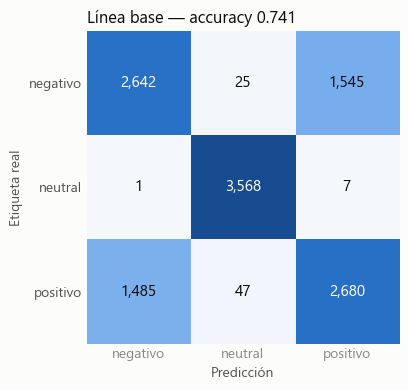

In [7]:
def graficar_confusion(ax, y_true, y_pred, titulo):
    cm = confusion_matrix(y_true, y_pred, labels=CLASES)
    ax.imshow(cm, cmap=RAMPA_AZUL, vmin=0, vmax=cm.sum(1).max())
    for i in range(3):
        for j in range(3):
            oscuro = cm[i, j] > 0.55 * cm.sum(1).max()
            ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center', fontsize=11, color='white' if oscuro else TINTA)
    ax.set_xticks(range(3), CLASES); ax.set_yticks(range(3), CLASES)
    ax.set_xlabel('Predicción'); ax.set_ylabel('Etiqueta real')
    ax.set_title(titulo, color=TINTA)
    ax.tick_params(length=0)
    for s in ax.spines.values(): s.set_visible(False)

fig, ax = plt.subplots(figsize=(4.6, 4))
graficar_confusion(ax, y, pred_base, f'Línea base — accuracy {accuracy_score(y, pred_base):.3f}')
plt.tight_layout(); plt.show()

**Diagnóstico:** la clase `neutral` está prácticamente resuelta (~99.8 % de recall), pero entre `positivo` y `negativo` la línea base acierta solo ≈63 %. Casi todo el error son confusiones positivo↔negativo en **reseñas mixtas**: la bolsa de palabras ve *"excelente"* y *"pésimo"* a la vez y no sabe cuál pesa más, porque descarta el orden.

## 5. Análisis del error: ¿qué opinión decide la etiqueta?
Para entender la regla que siguen las reseñas mixtas:
1. Partimos cada reseña en **cláusulas** (oraciones, y dentro de ellas en *", pero"*, *", aunque"*, *", y"*, …).
2. Entrenamos, dentro de cada fold y sin mirar el fold de validación, dos modelos auxiliares a nivel de documento: un **detector de opinión** (reseña polar frente a neutral) y un **modelo de polaridad** (positivo frente a negativo). Aplicados a cada cláusula, indican cuáles expresan opinión y con qué signo.
3. En las reseñas con opiniones de signo contrario medimos con qué frecuencia la etiqueta coincide con la **primera** opinión, con la **última** o con la **más intensa**, según el conector que introduce la última opinión.

In [8]:
FUERTES = ['pero al final', 'pero', 'aun asi', 'aun con eso', 'con todo', 'al final de cuentas', 'al final',
           'a fin de cuentas', 'sin embargo', 'no obstante', 'de todos modos', 'de todas formas', 'lo que si',
           'ahora bien', 'aunque']                                  # conectores adversativos "fuertes"
DEBILES = ['eso si', 'igual', 'total', 'en fin', 'en cambio']      # adversativos "débiles"
ADITIVOS = ['por otro lado', 'por otra parte', 'ademas', 'de paso', 'por cierto', 'tambien', 'y']


def oraciones(t):
    return [s for s in re.split(r'(?<=[.!?])\s+', t) if s] or ['']


RE_CLAUSULA = re.compile(r',\s*(?=(?:pero|aunque|y|eso si|en cambio|sin embargo|mientras que|aun asi)\b)|;\s*')


def clausulas(t):
    return [p.strip() for s in oraciones(t) for p in RE_CLAUSULA.split(s) if p.strip()]


RE_CONECTOR = re.compile(r'\b(' + '|'.join(re.escape(c) for c in sorted(FUERTES + DEBILES + ADITIVOS, key=len, reverse=True)) + r')\b')


def conector_de(clausula):
    m = RE_CONECTOR.search(clausula[:45])
    return m.group(1) if m else '(sin conector)'


def grupo_de(conector):
    if conector in FUERTES: return 'adversativo fuerte'
    if conector in DEBILES: return 'adversativo débil'
    return 'aditivo / sin conector'


print(f'{len(FUERTES)} conectores adversativos fuertes, {len(DEBILES)} débiles y {len(ADITIVOS)} aditivos')
print(clausulas(normalizar('La batería es excelente, pero la cámara resultó decepcionante. Eso sí, llegó rápido.')))

15 conectores adversativos fuertes, 5 débiles y 7 aditivos
['la bateria es excelente', 'pero la camara resulto decepcionante.', 'eso si, llego rapido.']


In [9]:
Xn = np.array([normalizar(t) for t in X])
filas = []
for tr_idx, va_idx in CV.split(Xn, y):
    v_op = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, min_df=2)
    detector = LogisticRegression(C=5, max_iter=5000).fit(v_op.fit_transform(Xn[tr_idx]), y[tr_idx] != 'neutral')
    polares = tr_idx[y[tr_idx] != 'neutral']
    v_pol = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, min_df=2)
    polaridad = LogisticRegression(C=5, max_iter=5000).fit(v_pol.fit_transform(Xn[polares]), y[polares] == 'positivo')

    idx = [i for i in va_idx if y[i] != 'neutral']
    cls = [clausulas(Xn[i]) for i in idx]
    planas = [c for cc in cls for c in cc]
    s_op = detector.decision_function(v_op.transform(planas)) - detector.intercept_[0]
    s_pol = polaridad.decision_function(v_pol.transform(planas))
    k = 0
    for i, cc in zip(idx, cls):
        so, spol = s_op[k:k + len(cc)], s_pol[k:k + len(cc)]; k += len(cc)
        ops = [(c, p) for c, o, p in zip(cc, so, spol) if o > 3]       # cláusulas con opinión
        if len(ops) < 2 or np.sign(ops[0][1]) == np.sign(ops[-1][1]) or min(abs(ops[0][1]), abs(ops[-1][1])) < 1:
            continue                                                    # solo reseñas mixtas claras
        es_pos = y[i] == 'positivo'
        mas_intensa = ops[0][1] if abs(ops[0][1]) > abs(ops[-1][1]) else ops[-1][1]
        con = conector_de(ops[-1][0])
        filas.append(dict(conector=con, grupo=grupo_de(con), primera=es_pos == (ops[0][1] > 0),
                          ultima=es_pos == (ops[-1][1] > 0), intensa=es_pos == (mas_intensa > 0)))

mixtas = pd.DataFrame(filas)
print(f'Reseñas mixtas analizadas: {len(mixtas)} de {(y != "neutral").sum()} polares\n')
agg = dict(n=('ultima', 'size'), etiqueta_igual_primera=('primera', 'mean'),
           etiqueta_igual_ultima=('ultima', 'mean'), etiqueta_igual_mas_intensa=('intensa', 'mean'))
por_grupo = mixtas.groupby('grupo').agg(**agg).round(3)
por_conector = mixtas.groupby(['conector', 'grupo']).agg(**agg).query('n >= 12').sort_values('etiqueta_igual_ultima', ascending=False).round(3)
display(por_grupo)
display(por_conector)

Reseñas mixtas analizadas: 1701 de 8424 polares



,n,etiqueta_igual_primera,etiqueta_igual_ultima,etiqueta_igual_mas_intensa
grupo,,,,
aditivo / sin conector,1039,0.480,0.520,0.494
adversativo débil,387,0.388,0.612,0.545
adversativo fuerte,275,0.084,0.916,0.636


,,n,etiqueta_igual_primera,etiqueta_igual_ultima,etiqueta_igual_mas_intensa
conector,grupo,,,,
con todo,adversativo fuerte,23,0.043,0.957,0.522
pero al final,adversativo fuerte,20,0.050,0.950,1.000
aun asi,adversativo fuerte,78,0.051,0.949,0.513
pero,adversativo fuerte,64,0.094,0.906,0.797
aunque,adversativo fuerte,32,0.094,0.906,0.688
al final,adversativo fuerte,21,0.143,0.857,0.571
lo que si,adversativo fuerte,16,0.188,0.812,0.688
igual,adversativo débil,16,0.250,0.750,0.750
y,aditivo / sin conector,48,0.292,0.708,0.438


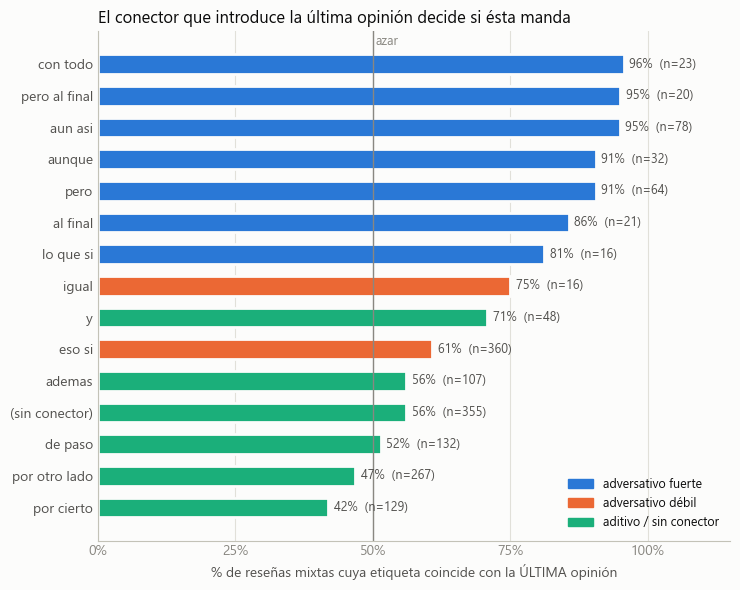

In [10]:
COLOR_GRUPO = {'adversativo fuerte': AZUL, 'adversativo débil': NARANJA, 'aditivo / sin conector': AQUA}
d = por_conector.reset_index().sort_values('etiqueta_igual_ultima')
fig, ax = plt.subplots(figsize=(7.5, 0.32 * len(d) + 1.2))
ax.barh(d.conector, 100 * d.etiqueta_igual_ultima, height=0.62, color=[COLOR_GRUPO[g] for g in d.grupo],
        edgecolor=SUPERFICIE, linewidth=2)
for yy, (v, n) in enumerate(zip(d.etiqueta_igual_ultima, d.n)):
    ax.text(100 * v + 1, yy, f'{100 * v:.0f}%  (n={n})', va='center', fontsize=9, color=TINTA2)
ax.axvline(50, color=TENUE, linewidth=1)
ax.text(50.5, len(d) - 0.4, 'azar', color=TENUE, fontsize=9)
ax.set_xlim(0, 115); ax.set_xticks([0, 25, 50, 75, 100], ['0%', '25%', '50%', '75%', '100%'])
ax.xaxis.grid(True); ax.set_axisbelow(True); ax.tick_params(length=0)
ax.set_xlabel('% de reseñas mixtas cuya etiqueta coincide con la ÚLTIMA opinión')
ax.set_title('El conector que introduce la última opinión decide si ésta manda', color=TINTA)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in COLOR_GRUPO.values()], labels=list(COLOR_GRUPO),
          loc='lower right', frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

**Hallazgos**
- Con un **conector adversativo fuerte** (*con todo, aun así, pero al final, aunque, pero…*) la etiqueta sigue a la **última** opinión en ~92 % de los casos: es la regla de *recencia* que menciona el enunciado.
- Con *"eso sí"* (el conector más frecuente) la última opinión gana solo ~61 % de las veces.
- Con conectores **aditivos** (*por otro lado, además, de paso, por cierto*) o sin conector, la etiqueta coincide con la primera opinión ~48 % de las veces, con la última ~52 % y con la más intensa ~49 %: con esta mirada **no hay señal de orden recuperable**.

**Consecuencias para el modelado**
1. La representación debe saber **dónde** aparece cada palabra: antes o después del último conector adversativo, y si está en la última oración (secciones 6–8).
2. Una parte de las reseñas mixtas parece ruido para cualquier modelo que solo vea el texto. En la sección 9 afinamos este diagnóstico con un análisis de las plantillas: el factor decisivo no es tanto el conector como el **tipo de opinión** (adjetivo o frase hecha).

## 6. Representación consciente del orden: bloques de texto
El transformador `Bloques` (sin parámetros entrenables) convierte cada reseña en varias "vistas" del texto, y luego **cada bloque se vectoriza por separado con TF-IDF**. Así la misma palabra tiene un peso distinto según dónde aparece: *"pésimo"* en el segmento que sigue a *"aun así"* pesa mucho más que *"pésimo"* antes del conector.

| Bloque | Contenido |
|---|---|
| `completo` | toda la reseña normalizada (bolsa de palabras clásica) |
| `post` | desde el **último conector adversativo** (fuerte o débil) hasta el final |
| `post_fuerte` | desde el último conector adversativo **fuerte** hasta el final |
| `post_debil` | desde el último conector adversativo **débil** (*eso sí, igual…*) hasta el final |
| `ultima` | la última oración |
| `penultima` | la penúltima oración |

Sigue siendo una representación de bolsa de palabras / n-gramas: solo cambia **qué fragmento** se vectoriza.

In [11]:
def _regex_conectores(lista):
    # Conector al inicio del texto o después de un signo de puntuación
    return re.compile(r'(?:^|(?<=[.!?,;])\s*)(?:' + '|'.join(re.escape(c) for c in sorted(lista, key=len, reverse=True)) + r')\b')


RE_FUERTE, RE_DEBIL, RE_ADVERSATIVO = _regex_conectores(FUERTES), _regex_conectores(DEBILES), _regex_conectores(FUERTES + DEBILES)


def desde_ultimo(texto, regex):
    # Fragmento desde la última aparición del conector hasta el final ('' si no hay conector)
    m = list(regex.finditer(texto))
    return texto[m[-1].start():] if m else ''


class Bloques(TransformerMixin, BaseEstimator):
    # Convierte textos crudos en un DataFrame con una columna de texto por bloque (sin parámetros entrenables)
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        T = [normalizar(t) for t in X]
        O = [oraciones(t) for t in T]
        return pd.DataFrame({
            'completo': T,
            'post': [desde_ultimo(t, RE_ADVERSATIVO) for t in T],
            'post_fuerte': [desde_ultimo(t, RE_FUERTE) for t in T],
            'post_debil': [desde_ultimo(t, RE_DEBIL) for t in T],
            'ultima': [o[-1] for o in O],
            'penultima': [o[-2] if len(o) > 1 else '' for o in O],
        })


print('Bloques generados:', list(Bloques().transform(['Texto de prueba.']).columns))

Bloques generados: ['completo', 'post', 'post_fuerte', 'post_debil', 'ultima', 'penultima']


In [12]:
ejemplo = train.text[2]
print(ejemplo, '\n')
B = Bloques().transform(X)
print('% de reseñas con conector adversativo fuerte:', round(100 * (B.post_fuerte != '').mean(), 1))
print('% de reseñas con conector adversativo débil :', round(100 * (B.post_debil != '').mean(), 1))
Bloques().transform([ejemplo]).T.rename(columns={0: 'contenido'})

Lo pedí a mediados de mes y me llegó en tres días, en su caja normal sin nada fuera de lo común. Lo uso en la oficina casi a diario desde entonces. El diseño se sintió durable desde el primer día. Aun así, la relación calidad-precio se ve desagradable con el tiempo. 



% de reseñas con conector adversativo fuerte: 26.0
% de reseñas con conector adversativo débil : 17.6


,contenido
completo,"lo pedi a mediados de mes y me llego en tres dias, en su caja normal sin nada fuera de lo comun. lo uso en la oficina casi a diario desde entonces. el diseno se sintio durable desde el primer dia...."
post,"aun asi, la relacion calidad-precio se ve desagradable con el tiempo."
post_fuerte,"aun asi, la relacion calidad-precio se ve desagradable con el tiempo."
post_debil,
ultima,"aun asi, la relacion calidad-precio se ve desagradable con el tiempo."
penultima,el diseno se sintio durable desde el primer dia.


## 7. Modelos base del ensemble v1
Todos se evalúan con la **misma** validación cruzada y guardamos sus probabilidades OOF para construir después el ensemble sin fuga de información.

- **`lr_palabras`**: TF-IDF de palabras (1-2 gramas) en los bloques `completo`, `post` y `ultima` + regresión logística.
- **`lr_pal_car`**: lo mismo con n-gramas de caracteres (`char_wb`, 2-5) en cada bloque: robusto a typos y tildes faltantes.
- **`svc_pal_car`**: misma representación con SVM lineal; `CalibratedClassifierCV` le da probabilidades para el voto suave.
- **`stacking`**: una regresión logística **por bloque** (los 6 bloques, palabras + caracteres) y un **HistGradientBoosting** como meta-clasificador sobre sus probabilidades. Al no ser lineal, el meta-modelo puede aprender reglas del tipo *"si el bloque tras el conector fuerte es muy negativo, ignorar lo anterior"*. `StackingClassifier` genera internamente las predicciones de los modelos base por validación cruzada, así que el meta-modelo no ve predicciones sobreajustadas.

Los hiperparámetros (C de la regresión logística en {2, 5, 10, 20}, C del SVM en {0.1, 0.3, 1}, rangos de n-gramas y combinaciones de bloques) se eligieron con esta misma validación cruzada; una búsqueda aleatoria posterior de 87 configuraciones confirmó que ya eran óptimos (±0.1 puntos).

In [13]:
def tfidf_palabras():
    return TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, min_df=2)


def tfidf_caracteres():
    return TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), sublinear_tf=True, min_df=3)


def vectorizar(bloques, vectorizadores):
    # Un vectorizador independiente por cada (bloque, tipo de n-grama)
    return ColumnTransformer([(f'{b}_{i}', v(), b) for b in bloques for i, v in enumerate(vectorizadores)])


BLOQUES_LINEALES = ['completo', 'post', 'ultima']
BLOQUES_STACKING = ['completo', 'post', 'post_fuerte', 'post_debil', 'ultima', 'penultima']


def modelo_lr_palabras():
    return Pipeline([('bloques', Bloques()),
                     ('vec', vectorizar(BLOQUES_LINEALES, [tfidf_palabras])),
                     ('clf', LogisticRegression(C=5, max_iter=5000))])


def modelo_lr_pal_car():
    return Pipeline([('bloques', Bloques()),
                     ('vec', vectorizar(BLOQUES_LINEALES, [tfidf_palabras, tfidf_caracteres])),
                     ('clf', LogisticRegression(C=5, max_iter=5000))])


def modelo_svc_pal_car():
    return Pipeline([('bloques', Bloques()),
                     ('vec', vectorizar(BLOQUES_LINEALES, [tfidf_palabras, tfidf_caracteres])),
                     ('clf', CalibratedClassifierCV(LinearSVC(C=0.3, random_state=SEED), cv=3))])


def modelo_stacking():
    por_bloque = [(b, Pipeline([('vec', vectorizar([b], [tfidf_palabras, tfidf_caracteres])),
                                ('clf', LogisticRegression(C=5, max_iter=5000))]))
                  for b in BLOQUES_STACKING]
    meta = HistGradientBoostingClassifier(learning_rate=0.05, max_iter=300, max_leaf_nodes=15, min_samples_leaf=40,
                                          early_stopping=False, random_state=0)
    return Pipeline([('bloques', Bloques()),
                     ('stack', StackingClassifier(por_bloque, final_estimator=meta, stack_method='predict_proba',
                                                  cv=StratifiedKFold(5, shuffle=True, random_state=1)))])


FABRICAS_V1 = {'stacking': modelo_stacking, 'lr_palabras': modelo_lr_palabras,
               'lr_pal_car': modelo_lr_pal_car, 'svc_pal_car': modelo_svc_pal_car}


def calcular_oof(fabricas, cv, prefijo=''):
    # Probabilidades out-of-fold (reseñas x 3 clases) de cada componente con la partición cv
    oof, segundos = {}, {}
    for nombre, fabrica in fabricas.items():
        t0 = time.time()
        oof[nombre] = cross_val_predict(fabrica(), X, y, cv=cv, method='predict_proba', n_jobs=N_JOBS)
        segundos[nombre] = time.time() - t0
        print(f'{prefijo}{nombre:12s} accuracy OOF = {accuracy_score(y, CLASES[oof[nombre].argmax(1)]):.4f}'
              f'   ({segundos[nombre]:.0f} s)', flush=True)
    return oof, segundos


print('Componentes del ensemble v1:', ', '.join(FABRICAS_V1))

Componentes del ensemble v1: stacking, lr_palabras, lr_pal_car, svc_pal_car


In [14]:
OOF, SEGUNDOS = calcular_oof(FABRICAS_V1, CV)
for nombre in FABRICAS_V1:
    RESUMEN[f'acc_{nombre}'] = accuracy_score(y, CLASES[OOF[nombre].argmax(1)])

stacking     accuracy OOF = 0.9012   (276 s)


lr_palabras  accuracy OOF = 0.8951   (12 s)


lr_pal_car   accuracy OOF = 0.8981   (48 s)


svc_pal_car  accuracy OOF = 0.8998   (45 s)


## 8. Ensemble v1 (voto suave ponderado)
El ensemble promedia las probabilidades de los componentes con pesos $w_i \ge 0$, $\sum w_i = 1$:

$$\hat{p}(c \mid x) = \sum_i w_i \, p_i(c \mid x), \qquad \hat{y} = \arg\max_c \hat{p}(c \mid x)$$

Buscamos los pesos en una rejilla (múltiplos de 0.1) maximizando la accuracy sobre las probabilidades **OOF**. Como elegir pesos mirando esas mismas predicciones es optimista, validamos la elección con un esquema **anidado**: se eligen los pesos con 4/5 de las reseñas y se mide la accuracy en el 1/5 restante (`StratifiedKFold(5, shuffle=True, random_state=123)` sobre las OOF). Esa accuracy **anidada** es la cifra honesta con la que comparamos ensembles.

En la sección 12 usamos las mismas funciones para el ensemble de 6 componentes, con una diferencia: allí los pesos se eligen con dos particiones de la validación cruzada.

In [15]:
def composiciones(n, k):
    # Tuplas de k enteros >= 0 que suman n, en orden lexicográfico (pesos = tupla / n)
    if k == 1:
        yield (n,)
        return
    for i in range(n + 1):
        for resto in composiciones(n - i, k - 1):
            yield (i,) + resto


def evaluar_rejilla(oof, nombres, paso=0.1):
    # Para cada combinación de pesos de la rejilla devuelve qué reseñas acierta el ensemble.
    # aciertos[j, i] = True si la combinación j acierta la reseña i: así cualquier subconjunto se evalúa sin recalcular.
    n = int(round(1 / paso))
    W = np.array(list(composiciones(n, len(nombres))), dtype=float) / n
    A = np.stack([np.asarray(oof[m], dtype=float) for m in nombres])          # componentes x reseñas x clases
    yi = np.searchsorted(CLASES, y)
    aciertos = np.empty((len(W), len(y)), dtype=bool)
    for j, w in enumerate(W):
        aciertos[j] = np.tensordot(w, A, axes=1).argmax(1) == yi
    return W, aciertos


def _lista(aciertos):
    # Una matriz de aciertos (una partición) o una lista de matrices (una por partición de la validación cruzada)
    return list(aciertos) if isinstance(aciertos, (list, tuple)) else [aciertos]


def mejores_pesos(W, aciertos, nombres, top=10, etiquetas=None):
    # Las `top` mejores combinaciones según la accuracy OOF (con varias particiones, según su media).
    # En empate gana la primera combinación de la rejilla.
    accs = [ac.mean(1) for ac in _lista(aciertos)]
    media = np.mean(accs, axis=0)
    filas = []
    for j in np.argsort(-media, kind='stable')[:top]:
        fila = dict(zip(nombres, W[j]))
        if len(accs) == 1:
            fila['accuracy_oof'] = media[j]
        else:
            fila.update({f'accuracy_oof_{e}': a[j] for e, a in zip(etiquetas, accs)})
            fila['accuracy_oof_media'] = media[j]
        filas.append(fila)
    return pd.DataFrame(filas).round(4)


def seleccion_anidada(W, aciertos, nombres, seed=SEED_ANIDADO, etiquetas=None, aplicar=None):
    # Validación anidada de la elección de pesos: en cada una de 5 partes, los pesos se eligen con las otras 4/5 de
    # las reseñas (accuracy OOF media de las particiones) y se evalúan en la parte no vista. `aplicar` evalúa esos
    # mismos pesos sobre otras matrices de aciertos (sección 13). Devuelve la tabla por parte y, para cada partición,
    # el vector de aciertos anidados: si cada reseña se acierta con pesos elegidos sin mirarla.
    eleccion = _lista(aciertos)
    evaluar_en = eleccion if aplicar is None else _lista(aplicar)
    columnas = (['accuracy_parte_no_vista'] if etiquetas is None and len(evaluar_en) == 1
                else [f'accuracy_no_vista_{e}' for e in (etiquetas or range(len(evaluar_en)))])
    anidados = np.zeros((len(evaluar_en), len(y)), dtype=bool)
    filas = []
    for a, b in StratifiedKFold(5, shuffle=True, random_state=seed).split(y, y):
        j = int(np.argmax(np.mean([ac[:, a].mean(1) for ac in eleccion], axis=0)))
        fila = dict(zip(nombres, W[j]))
        for k, ac in enumerate(evaluar_en):
            anidados[k, b] = ac[j, b]
            fila[columnas[k]] = ac[j, b].mean()
        filas.append(fila)
    return pd.DataFrame(filas).round(4), anidados


def prob_ensemble(oof, pesos):
    return sum(w * np.asarray(oof[m], dtype=float) for m, w in pesos.items() if w > 0)


def mcnemar(acierta_nuevo, acierta_ref):
    # Prueba exacta de McNemar (binomial, dos colas) a partir de los aciertos (True / False) de dos modelos
    a, b = np.asarray(acierta_nuevo, dtype=bool), np.asarray(acierta_ref, dtype=bool)
    gana, pierde = int((a & ~b).sum()), int((~a & b).sum())
    n, k = gana + pierde, min(gana, pierde)
    p = min(1.0, 2 * sum(comb(n, i) for i in range(k + 1)) / 2 ** n) if n else 1.0
    return dict(gana=gana, pierde=pierde, p=p)


print('Combinaciones de la rejilla (paso 0.1): 4 componentes ->', sum(1 for _ in composiciones(10, 4)),
      '| 6 componentes ->', sum(1 for _ in composiciones(10, 6)))

Combinaciones de la rejilla (paso 0.1): 4 componentes -> 286 | 6 componentes -> 3003


In [16]:
NOMBRES_V1 = list(FABRICAS_V1)
aciertos_modelos = pd.DataFrame({n: CLASES[OOF[n].argmax(1)] == y for n in NOMBRES_V1})
print('Correlación de aciertos entre modelos (más baja = más complementarios):')
display(aciertos_modelos.corr().round(2))

W_v1, ACIERTOS_V1 = evaluar_rejilla(OOF, NOMBRES_V1)
print(f'Combinaciones evaluadas: {len(W_v1)}. Las 10 mejores:')
display(mejores_pesos(W_v1, ACIERTOS_V1, NOMBRES_V1))

anidado_v1, aciertos_anidados_v1 = seleccion_anidada(W_v1, ACIERTOS_V1, NOMBRES_V1)
display(anidado_v1)
PESOS_V1 = {n: float(w) for n, w in zip(NOMBRES_V1, W_v1[int(np.argmax(ACIERTOS_V1.mean(1)))])}
RESUMEN['v1_oof'] = ACIERTOS_V1.mean(1).max()
RESUMEN['v1_anidado'] = aciertos_anidados_v1.mean()
print(f'Ensemble v1: accuracy OOF {RESUMEN["v1_oof"]:.4f} | selección de pesos anidada {RESUMEN["v1_anidado"]:.4f}')
print('Pesos óptimos en la rejilla:', PESOS_V1)

Correlación de aciertos entre modelos (más baja = más complementarios):


,stacking,lr_palabras,lr_pal_car,svc_pal_car
stacking,1.00,0.54,0.56,0.56
lr_palabras,0.54,1.00,0.82,0.82
lr_pal_car,0.56,0.82,1.00,0.86
svc_pal_car,0.56,0.82,0.86,1.00


Combinaciones evaluadas: 286. Las 10 mejores:


,stacking,lr_palabras,lr_pal_car,svc_pal_car,accuracy_oof
0,0.5,0.4,0.0,0.1,0.9069
1,0.5,0.3,0.1,0.1,0.9067
2,0.5,0.3,0.0,0.2,0.9066
3,0.5,0.4,0.1,0.0,0.9063
4,0.5,0.5,0.0,0.0,0.9063
5,0.5,0.2,0.2,0.1,0.9060
6,0.5,0.2,0.0,0.3,0.9058
7,0.5,0.3,0.2,0.0,0.9058
8,0.6,0.4,0.0,0.0,0.9058
9,0.5,0.2,0.1,0.2,0.9057


,stacking,lr_palabras,lr_pal_car,svc_pal_car,accuracy_parte_no_vista
0,0.5,0.4,0.0,0.1,0.9029
1,0.5,0.4,0.0,0.1,0.9108
2,0.5,0.3,0.1,0.1,0.9071
3,0.5,0.4,0.0,0.1,0.9129
4,0.5,0.4,0.0,0.1,0.8996


Ensemble v1: accuracy OOF 0.9069 | selección de pesos anidada 0.9067


Pesos óptimos en la rejilla: {'stacking': 0.5, 'lr_palabras': 0.4, 'lr_pal_car': 0.0, 'svc_pal_car': 0.1}


In [17]:
pred_v1 = CLASES[prob_ensemble(OOF, PESOS_V1).argmax(1)]
tipo = np.select([y == 'neutral', B.post_fuerte != '', B.post_debil != '',
                  B.completo.str.contains(r'\b(?:por otro lado|por otra parte|ademas|de paso|por cierto|tambien)\b')],
                 ['neutral', 'con adversativo fuerte', 'con adversativo débil (eso sí…)', 'con conector aditivo'],
                 default='sin conector')
pd.DataFrame({'tipo': tipo, 'base': pred_base == y, 'ensemble': pred_v1 == y}).groupby('tipo').agg(
    n=('base', 'size'), acc_linea_base=('base', 'mean'), acc_ensemble_v1=('ensemble', 'mean')
).round(3).sort_values('acc_ensemble_v1', ascending=False)

,n,acc_linea_base,acc_ensemble_v1
tipo,,,
neutral,3576,0.998,0.997
con adversativo fuerte,2917,0.585,0.971
sin conector,2650,0.737,0.892
con adversativo débil (eso sí…),1657,0.566,0.804
con conector aditivo,1200,0.604,0.656


**Interpretación.** La superficie de pesos es plana: las diez mejores combinaciones están a menos de 0.15 puntos de la mejor, y la selección anidada estima prácticamente lo mismo que la mejor combinación sobre todas las OOF (0.9067 frente a 0.9069), así que el sobreajuste de los pesos es mínimo. El modelo v1 que se entregó usaba los pesos *stacking 0.5 · lr_palabras 0.1 · lr_pal_car 0.3 · svc_pal_car 0.1*, equivalentes dentro del ruido, y obtuvo **0.90111** en el *leaderboard* público de Kaggle.

El ensemble v1 resuelve casi por completo las reseñas con conector adversativo fuerte. El error restante se concentra en las reseñas con conector aditivo o *"eso sí"*. La siguiente sección explica por qué.

## 9. Hallazgo: dos familias de plantillas de opinión
Para ir más allá del conector escribimos un **analizador (parser) determinista de las plantillas** con que parecen estar generadas las reseñas. El inventario se escribió a mano leyendo reseñas de `train` (su sesgo de diseño se discute en las secciones 13 y 18):
- **Opiniones tipo A — aspecto + verbo copulativo + adjetivo**: *"la batería **resultó** excelente"*, *"el diseño **se ve** frágil"*, con 36 verbos copulativos (*es, fue, resultó, se ve, se siente, quedó…*), 90 adjetivos (50 positivos y 40 negativos) y sus modificadores y negaciones (*"poco cómodo"*, *"no fiable"*).
- **Opiniones tipo B — frases hechas**: 59 predicados fijos como *"fue todo un acierto"*, *"me hizo la vida más fácil"*, *"no vale lo que cuesta"*, *"me arrepiento de haberlo comprado"*.
- 34 **conectores** que introducen cada opinión (fuertes, débiles y aditivos), 17 **cierres ambivalentes** (*"ni tan bueno ni tan malo"*, *"cada quien que juzgue"*, *"sopésalo tú mismo"*…) y oraciones de **relleno** (envío, peso, garantía) después de la última opinión.

El parser también reconoce 54 aspectos (*batería, pantalla, envío…*), pero solo para mostrar ejemplos: no entran en los rasgos del modelo.

Antes de buscar opiniones, un **corrector de typos** reemplaza cada palabra poco frecuente de más de 3 letras (aparece menos de 5 veces) por la palabra frecuente más común a distancia de edición 1 (*"epsectacular"* → *"espectacular"*). El corrector solo cuenta frecuencias de palabras, sin etiquetas. Cuando forma parte de un modelo se ajusta dentro de cada fold (sección 10).

In [18]:
# ---------------------------------------------------------------- corrector de typos (frecuencias de palabras, sin etiquetas)
LETRAS = 'abcdefghijklmnopqrstuvwxyzñ'


def ediciones_1(w):
    # Todas las cadenas a distancia de edición 1 de w: borrados, transposiciones, sustituciones e inserciones
    cortes = [(w[:i], w[i:]) for i in range(len(w) + 1)]
    borrados = [a + b[1:] for a, b in cortes if b]
    transpuestas = [a + b[1] + b[0] + b[2:] for a, b in cortes if len(b) > 1]
    sustituidas = [a + c + b[1:] for a, b in cortes if b for c in LETRAS]
    insertadas = [a + c + b for a, b in cortes for c in LETRAS]
    return set(borrados + transpuestas + sustituidas + insertadas)


class CorrectorTypos:
    # Reemplaza las palabras de más de 3 letras con frecuencia < frec_min por la palabra frecuente más común a
    # distancia de edición 1 ('lleego' -> 'llego'). Solo aprende frecuencias de los textos que recibe en ajustar().
    def __init__(self, frec_min=5):
        self.frec_min = frec_min

    def ajustar(self, textos_normalizados):
        self.frecuencia = collections.Counter(w for t in textos_normalizados for w in re.findall(r'[a-zñ]+', t))
        self.vocabulario = {w for w, k in self.frecuencia.items() if k >= self.frec_min}
        self.cache = {}
        return self

    def corregir_palabra(self, w):
        if w in self.vocabulario or len(w) <= 3:
            return w
        if w not in self.cache:
            candidatas = sorted(v for v in ediciones_1(w) if v in self.vocabulario)   # orden fijo: desempate reproducible
            self.cache[w] = max(candidatas, key=lambda v: self.frecuencia[v]) if candidatas else w
        return self.cache[w]

    def corregir(self, texto):
        return re.sub(r'[a-zñ]+', lambda m: self.corregir_palabra(m.group()), texto)


demo = CorrectorTypos(frec_min=2).ajustar(['llego espectacular'] * 3)
print('Corrector (ejemplo):', 'lleego epsectacular ->', demo.corregir('lleego epsectacular'))

Corrector (ejemplo): lleego epsectacular -> llego espectacular


In [19]:
# ---------------------------------------------------------------- inventario de las plantillas (escrito a mano leyendo train)
# Los aspectos solo se usan para mostrar ejemplos (columna 'aspecto'); no entran en los rasgos del componente.
ASPECTOS = ['instalacion', 'control remoto', 'resolucion', 'acabado', 'calidad', 'portabilidad',
            'resistencia al agua', 'atencion al cliente', 'procesador', 'interfaz', 'servicio',
            'duracion de la carga', 'cable', 'pantalla tactil', 'microfono', 'tamano', 'diseno',
            'boton de encendido', 'construccion', 'correa', 'manual de uso', 'autonomia', 'bateria', 'envio',
            'velocidad', 'terminacion', 'pantalla', 'ensamblaje', 'senal', 'menu de ajustes', 'motor',
            'nitidez de la imagen', 'camara', 'sonido', 'rendimiento', 'cargador', 'sistema de sonido', 'funda',
            'carcasa', 'app del fabricante', 'tapa', 'comodidad', 'ventilador', 'teclado', 'sistema de carga',
            'empaque', 'memoria', 'material', 'soporte tecnico', 'peso', 'conexion', 'aplicacion', 'ergonomia',
            'color']
RE_ASPECTO = re.compile(r'\b(?:el|la|los|las|al|del|lo de la|lo del)\s+(' +
                        '|'.join(sorted(ASPECTOS, key=len, reverse=True)) + r')\b')

# Plantilla A: verbo copulativo + (modificador) + adjetivo
COPULAS = ['me parecio', 'me resulto ser', 'me resulto', 'resulto ser', 'resulto', 'quedo', 'se ve', 'se siente',
           'se sintio', 'se mantuvo', 'termino siendo', 'luce', 'es', 'esta', 'fue', 'me salio', 'salio',
           'me quedo', 'anda', 'se nota', 'se volvio', 'funciona', 'sigue siendo', 'sigue', 'me parece', 'parece',
           'me ha parecido', 'se ha mantenido', 'me termino pareciendo', 'termino pareciendo', 'vino', 'me resulta',
           'resulta', 'queda', 'se sigue viendo', 'estuvo']
ADJ_POSITIVOS = ['robust[oa]', 'correct[oa]', 'nitid[oa]', 'impecable', 'liger[oa]', 'sobresaliente', 'optim[oa]',
                 'redond[oa]', 'durable', 'resistente', 'excelente', 'espectacular', 'comodisim[oa]', 'superior',
                 'decente', 'potente', 'agradable', 'estupend[oa]', 'eficiente', 'fiable', 'practic[oa]', 'solid[oa]',
                 'buenisim[oa]', 'precis[oa]', 'confiable', 'cumplidor[a]?', 'formidable', 'comod[oa]', 'rapidisim[oa]',
                 'veloz', 'funcional', 'complet[oa]', 'buen[oa]', 'notable', 'bien hech[oa]', 'bien lograd[oa]',
                 'bien construid[oa]', 'bien terminad[oa]', 'lograd[oa]', 'de maravilla', 'genial', 'perfect[oa]',
                 'ideal', 'brillante', 'increible', 'fantastic[oa]', 'bien', 'de buena calidad', 'de calidad',
                 'muy buen[oa]']
ADJ_NEGATIVOS = ['defectuos[oa]', 'imprecis[oa]', 'ordinari[oa]', 'incomod[oa]', 'chapucer[oa]', 'aparatos[oa]',
                 'terrible', 'inconsistente', 'malisim[oa]', 'floj[oa]', 'pobre', 'olvidable', 'debil', 'lentisim[oa]',
                 'limitad[oa]', 'inestable', 'torpe', 'deficiente', 'delicad[oa]', 'mediocre', 'basic[oa]',
                 'pesim[oa]', 'fragil', 'ruidos[oa]', 'incumplidor[a]?', 'desagradable', 'corriente', 'endeble',
                 'decepcionante', 'mal hech[oa]', 'mal terminad[oa]', 'mal construid[oa]', 'horrible', 'bastante mal',
                 'mal', 'lent[oa]', 'malo', 'mala', 'de mala calidad', 'de lo peor']
MODIFICADOR = r'(?:(?P<mod>muy|bastante|demasiado|super|algo|un poco|poco|nada|tan|re)\s+)?'
RE_COPULA_ADJETIVO = re.compile(r'\b(?P<cop>' + '|'.join(sorted(COPULAS, key=len, reverse=True)) + r')\s+' + MODIFICADOR +
                                r'(?P<adj>' + '|'.join(sorted(ADJ_POSITIVOS + ADJ_NEGATIVOS, key=len, reverse=True)) + r')\b')
RE_ADJ_POSITIVO = re.compile(r'^(?:' + '|'.join(ADJ_POSITIVOS) + r')$')

# Plantilla B: frases hechas. El prefijo de la clave es su polaridad semántica (p_ positiva, n_ negativa); el
# componente estructural vuelve a aprender la polaridad de cada clave dentro de cada fold.
FRASES_HECHAS = {
    'p_cumple_sobra': r'cumple de sobra',
    'p_vida_facil': r'me hizo la vida (?:mas|muy) facil',
    'p_sorprendio_bien': r'me sorprendio para bien',
    'p_cada_peso': r'cada peso que pague por .{0,40}? valio la pena|cada peso que pague valio la pena|valio cada peso',
    'p_me_encanto': r'\bme encanto\b|\bme encantaron\b',
    'p_feliz': r'\bestoy feliz con|\btermine feliz con|\bquede feliz con|me tiene feliz|me dejo feliz|estoy feliz|sigo estando feliz|feliz con',
    'p_contento': r'me tiene content[oa]|me dejo content[oa]|muy content[oa]|quede content[oa]|estoy content[oa]',
    'p_satisfecho': r'mas que satisfech[oa]|quede satisfech[oa]|muy satisfech[oa]',
    'p_repetiria': r'repetiria la compra',
    'p_recomiendo_sin': r'l[oa] recomiendo sin (?:pensarlo|dudarlo)|recomiendo .{0,30}?sin dudarlo',
    'p_mucho_mejor': r'mucho mejor de lo que',
    'p_me_alegra': r'me alegra haber elegido|me alegra haberl[oa] elegido|me alegra haberl[oa] comprado',
    'p_tal_como': r'respondio tal como esperaba|tal como esperaba',
    'p_sola_queja': r'ni una sola queja',
    'p_supero': r'supero todas mis expectativas|supero mis expectativas',
    'p_vale_pena': r'vale totalmente la pena|vale la pena',
    'p_cinco_estrellas': r'cinco estrellas',
    'p_ojos_cerrados': r'con los ojos cerrados',
    'p_encantado': r'quede encantad[oa] con|quede encantad[oa]|quedo encantad[oa]|me quedo encantad[oa]',
    'p_sin_pensarlo': r'volveria a comprar\w* .{0,40}?sin pensarlo|volveria a comprar\w* sin pensarlo|sin pensarlo dos veces',
    'p_justo_buscando': r'justo lo que (?:estaba buscando|buscaba|necesitaba)',
    'p_acierto': r'todo un acierto',
    'p_encima_media': r'por encima de la media',
    'p_maravilla': r'funciona de maravilla|de maravilla',
    'p_dejo_encantado': r'me dejo encantad[oa]|me tiene encantad[oa]',
    'p_volvi_comprar': r'volvi a comprar',
    'p_con_creces': r'cumple con creces|con creces',
    'p_ni_una_queja': r'ni una queja|una sola queja|no tengo queja|no me quejo',
    'p_me_gusto': r'me gusto (?:bastante|mucho)|me gustaron|me termino gustando|termino gustandome|si me gusto|me gusto',
    'n_no_vale': r'no vale lo que cuesta',
    'n_dolor_cabeza': r'mas de un dolor de cabeza|dolor de cabeza',
    'n_para_nada': r'no es para nada lo que esperaba|para nada lo que esperaba',
    'n_se_dano': r'se dano antes de lo que esperaba|se dano',
    'n_defraudo': r'defraudo todas mis expectativas|defraudo',
    'n_tire_dinero': r'tire el dinero',
    'n_decepciono': r'me decepciono|me decepcionaron',
    'n_me_arrepiento': r'me arrepiento de haber|me arrepiento es de haber|me arrepenti de haber\w*',
    'n_arrepentido': r'arrepentid[oa] de haber',
    'n_problemas': r'no pare de tener problemas|no para de darme problemas|no paro de darme problemas|me ha dado problemas',
    'n_no_convencio': r'no me convencio|no me convence|no me termino de convencer',
    'n_mal_rato': r'mas de un mal rato',
    'n_debajo_aceptable': r'por debajo de lo aceptable',
    'n_peor_parece': r'las cosas que peor',
    'n_molesto': r'quede muy molest[oa]|quede molest[oa]',
    'n_no_recomiendo': r'no l[oa] le recomiendo|no le recomiendo|no se l[oa]s? recomiendo|no l[oa] recomiendo|no se l[oa]s? recomendaria|recomendaria a nadie',
    'n_dejo_molesto': r'me dejo (?:muy )?molest[oa]',
    'n_complicaciones': r'me trajo complicaciones|me dio problemas|dio problemas|me trajo problemas',
    'n_no_funciono': r'no me funciono como esperaba|nunca me funciono como esperaba',
    'n_desilusiono': r'me desilusiono',
    'n_fue_error': r'fue un error',
    'n_una_estrella': r'una sola estrella|una estrella',
    'n_queda_corto': r'se queda muy cort[oa]|se queda cort[oa]',
    'n_ni_regalado': r'ni regalad[oa]|ni aunque me l[oa] regal\w*|ni me l[oa] regalaron',
    'n_harto': r'termine hart[oa]|quede hart[oa]|termino hart[oa]',
    'n_error_compra': r'un error de compra',
    'n_debajo_media': r'por debajo de la media',
    'n_bastante_mal': r'funciona bastante mal',
    'n_no_gusto': r'no me gusto nada|no me gusto',
    'n_de_lo_peor': r'de lo peor',
}
RE_FRASES_HECHAS = [(k, re.compile(r'\b(?:' + v + r')')) for k, v in FRASES_HECHAS.items()]

# Cierres ambivalentes (se buscan en las oraciones posteriores a la última opinión)
CIERRES_AMBIVALENTES = {
    'c_juzgue': r'cada quien que juzgue|que cada quien juzgue|cada quien juzgue',
    'c_gustos': r'para gustos,? colores',
    'c_dudas': r'sigo con (?:dudas|la duda)|con la duda|me quede con la duda|sigo dudando|dudando',
    'c_fufa': r'ni fu ni fa',
    'c_criterio_cada': r'a criterio de cada uno',
    'c_criterio_tu': r'a tu criterio|a su criterio|a criterio',
    'c_no_sabria': r'no sabria (?:bien )?que (?:recomendar|pensar|decir)|no se bien que (?:pensar|decir|recomendar)|no se que (?:pensar|decir)',
    'c_hay_todo': r'hay de todo',
    'c_sopesalo': r'sopesalo|sopesenlo',
    'c_no_decido': r'no me decido|no me termino de decidir|sin decidirme|no termino de decidir',
    'c_mejor_peor': r'ni lo mejor ni lo peor',
    'c_bueno_malo': r'ni tan bueno ni tan malo',
    'c_ahi_dejo': r'ahi lo dejo|ahi queda',
    'c_sentimientos': r'sentimientos encontrados',
    'c_conclusiones': r'sacara sus conclusiones|saque sus conclusiones|sus propias conclusiones',
    'c_otras_no': r'otras no|lo uno y lo otro|unas cosas? (?:buenas?|mejor)|unos detalles mejor que otros',
    'c_vueltas': r'dandole vueltas|vuelta al asunto',
}
RE_CIERRES = [(k, re.compile(r'\b(?:' + v + r')')) for k, v in CIERRES_AMBIVALENTES.items()]

# Conectores que pueden introducir una opinión (lista ampliada respecto a la sección 5)
CONECTORES_PARSER = {
    'fuerte': ['pero al final', 'pero', 'aun asi', 'aun con eso', 'con todo', 'al final de cuentas', 'al final',
               'a fin de cuentas', 'sin embargo', 'no obstante', 'de todos modos', 'de todas formas', 'lo que si',
               'ahora bien', 'aunque', 'el detalle es que', 'lo curioso es que', 'mientras que', 'eso no quita'],
    'debil': ['eso si', 'igual', 'total', 'en fin', 'en cambio', 'ahora'],
    'aditivo': ['por otro lado', 'por otra parte', 'ademas', 'de paso', 'por cierto', 'tambien', 'aparte',
                'encima', 'y'],
}
_LISTA_CONECTORES = sorted([(c, t) for t, cs in CONECTORES_PARSER.items() for c in cs], key=lambda x: -len(x[0]))
RE_CONECTOR_PARSER = re.compile(r'\b(' + '|'.join(re.escape(c) for c, _ in _LISTA_CONECTORES) + r')\b')
TIPO_CONECTOR = {c: t for c, t in _LISTA_CONECTORES}

print(f'Inventario: {len(ASPECTOS)} aspectos, {len(COPULAS)} verbos copulativos, {len(ADJ_POSITIVOS)} + {len(ADJ_NEGATIVOS)} '
      f'adjetivos (positivos + negativos), {len(FRASES_HECHAS)} frases hechas, {len(CIERRES_AMBIVALENTES)} cierres ambivalentes, '
      f'{len(_LISTA_CONECTORES)} conectores')

Inventario: 54 aspectos, 36 verbos copulativos, 50 + 40 adjetivos (positivos + negativos), 59 frases hechas, 17 cierres ambivalentes, 34 conectores

In [20]:
# ---------------------------------------------------------------- analizador de una reseña (texto normalizado y corregido)
def oraciones_parser(t):
    return [s for s in re.split(r'(?<=[.!?])\s+', t.strip()) if s] or ['']


RE_FRAGMENTO = re.compile(r',\s+|;\s+|\s+y\s+(?=(?:el|la|los|las|lo|le|me|no|estoy|quede|siento|termine|recomiendo|'
                          r'volveria|cada|ni)\b)|\s+(?=(?:pero|aunque|mientras que|sin embargo)\b)')


def fragmentos(s):
    # Divide una oración en fragmentos (comas, punto y coma, ' y ' + inicio de cláusula, 'pero', 'aunque'...)
    # y devuelve [(inicio, fin, separador_previo)]
    salida, pos, sep = [], 0, ''
    for m in RE_FRAGMENTO.finditer(s):
        salida.append((pos, m.start(), sep))
        sep = m.group(0).strip() or ' '
        pos = m.end()
    salida.append((pos, len(s), sep))
    return [(a, b, sp_) for a, b, sp_ in salida if s[a:b].strip(' .!?')]


def nucleos_de_opinion(f):
    # [(clave, inicio, fin)] de los núcleos de opinión de un fragmento, sin solapes (el más largo primero).
    # Clave: 'p_.../n_...' para frases hechas (plantilla B); 'a+:adjetivo' / 'a-:adjetivo' para cópula + adjetivo (A)
    hits = []
    for k, rx in RE_FRASES_HECHAS:
        for m in rx.finditer(f):
            hits.append((k, m.start(), m.end()))
    for m in RE_COPULA_ADJETIVO.finditer(f):
        adj = m.group('adj')
        if adj in ('bien', 'mal') and m.group('cop') in ('es', 'esta', 'fue', 'sigue'):
            continue                                      # 'esta bien empacado' no es una opinión
        polar = 'a+' if RE_ADJ_POSITIVO.match(adj) else 'a-'
        mod = m.group('mod') or ''
        if mod in ('poco', 'nada'):                       # 'poco comodo' invierte la polaridad
            polar = 'a-' if polar == 'a+' else 'a+'
        elif re.search(r'\bno\s+$', f[max(0, m.start() - 4):m.start()]):   # 'no es fiable' también
            polar = 'a-' if polar == 'a+' else 'a+'
            mod = 'no'
        base = re.sub(r'[oa]$', '', adj) if ' ' not in adj else adj
        hits.append((f'{polar}:{mod + " " if mod in ("poco", "nada", "no") else ""}{base}', m.start(), m.end()))
    hits.sort(key=lambda h: (h[1], -(h[2] - h[1])))
    salida, fin = [], -1
    for h in hits:
        if h[1] >= fin:
            salida.append(h)
            fin = h[2]
    return salida


def analizar_resena(t):
    # Devuelve las oraciones, la lista de opiniones (en orden) y el cierre ambivalente, si lo hay
    S = oraciones_parser(t)
    ops = []
    for si, s in enumerate(S):
        frs = fragmentos(s)
        fin_previo = 0
        for a, b, sep in frs:
            f = s[a:b]
            nucleos = nucleos_de_opinion(f)
            if not nucleos:
                continue
            for j, (k, ca, cb) in enumerate(nucleos):     # varios núcleos en un fragmento -> una opinión por núcleo
                nb = nucleos[j + 1][1] if j + 1 < len(nucleos) else len(f)
                pa = nucleos[j - 1][2] if j > 0 else 0
                ops.append(dict(oracion=si, clave=k, fragmento=f[pa:nb], antes=f[pa:ca], despues=f[cb:nb],
                                separador=sep if j == 0 else 'y', previo=s[fin_previo:a] if j == 0 else '',
                                ini=a + pa, fin=a + nb, texto_oracion=s))
            fin_previo = b
    for j, o in enumerate(ops):
        sig = ops[j + 1] if j + 1 < len(ops) and ops[j + 1]['oracion'] == o['oracion'] else None
        o['posterior'] = o['texto_oracion'][o['fin']:(sig['ini'] if sig else len(o['texto_oracion']))]
        asp = RE_ASPECTO.search(o['fragmento'])
        o['aspecto'] = asp.group(1) if asp else ''
        contexto = o['previo'] + ' ' + o['antes'] + ' ' + o['separador']
        cs = RE_CONECTOR_PARSER.findall(contexto)
        o['conector'] = cs[-1] if cs else ''
        o['tipo_conector'] = TIPO_CONECTOR.get(o['conector'], 'ninguno')
    # cierre ambivalente en una oración posterior a la última opinión...
    ultima_si = ops[-1]['oracion'] if ops else -1
    cierre, oracion_cierre = '', -1
    for si in range(len(S) - 1, ultima_si, -1):
        for k, rx in RE_CIERRES:
            if rx.search(S[si]):
                cierre, oracion_cierre = k, si
                break
        if cierre:
            break
    # ...o dentro de la misma oración, después de la última opinión
    cierre_en_linea = ''
    if ops and not cierre:
        for k, rx in RE_CIERRES:
            if rx.search(ops[-1]['posterior']):
                cierre_en_linea = k
                break
    return dict(oraciones=S, opiniones=ops, cierre=cierre, oracion_cierre=oracion_cierre,
                cierre_en_linea=cierre_en_linea)


def signo_semantico(clave):
    return 1 if (clave.startswith('p_') or clave.startswith('a+')) else -1


def es_adjetival(o):
    return o['clave'][:2] in ('a+', 'a-')


demo = analizar_resena('el diseno se ve fragil. aun asi, la verdad fue todo un acierto. trae garantia de un ano.')
print('Ejemplo de análisis:', [(o['clave'], o['aspecto'], o['conector'] or '-') for o in demo['opiniones']],
      '| cierre:', demo['cierre'] or '-', '| oraciones:', len(demo['oraciones']))

Ejemplo de análisis: [('a-:fragil', 'diseno', '-'), ('p_acierto', '', 'aun asi')] | cierre: - | oraciones: 3


In [21]:
# Análisis descriptivo de todo train: corrector ajustado con los textos de train (sin etiquetas) y polaridad semántica
t0 = time.time()
corrector_global = CorrectorTypos().ajustar([normalizar(t) for t in X])
ANALISIS = [analizar_resena(corrector_global.corregir(normalizar(t))) for t in X]
print(f'{len(ANALISIS)} reseñas analizadas en {time.time() - t0:.0f} s')

GRUPOS = ['sin opinión detectada', 'una opinión o coherentes', 'mixta A (alguna cópula + adjetivo)', 'mixta B (solo frases hechas)']
FINALES = ['termina en opinión', 'relleno después', 'cierre ambivalente']


def celda_estructural(p):
    # (grupo, final) de una reseña según el parser, con la polaridad semántica del inventario
    ops = p['opiniones']
    if not ops:
        return GRUPOS[0], '—'
    signos = [signo_semantico(o['clave']) for o in ops]
    ult = ops[-1]
    hay_cierre = bool(p['cierre'] or p['cierre_en_linea'])
    relleno = len(p['oraciones']) - 1 - ult['oracion'] - (1 if p['oracion_cierre'] > ult['oracion'] else 0)
    final = FINALES[2] if hay_cierre else (FINALES[1] if relleno > 0 else FINALES[0])
    if len(set(signos)) == 1:
        return GRUPOS[1], final
    return (GRUPOS[2] if any(es_adjetival(o) for o in ops) else GRUPOS[3]), final


def etiqueta_por_regla(p):
    # Regla: sin opinión -> neutral; si no, el signo de la ÚLTIMA opinión
    ops = p['opiniones']
    if not ops:
        return 'neutral'
    return 'positivo' if signo_semantico(ops[-1]['clave']) == 1 else 'negativo'


CELDAS = pd.DataFrame([celda_estructural(p) for p in ANALISIS], columns=['grupo', 'final'])
CELDAS['regla_ultima'] = [etiqueta_por_regla(p) for p in ANALISIS] == y
CELDAS['ensemble_v1'] = pred_v1 == y
print('Opiniones detectadas por reseña:', pd.Series([len(p['opiniones']) for p in ANALISIS]).clip(upper=4).value_counts().sort_index().to_dict(), '(4 = 4 o más)')

12000 reseñas analizadas en 11 s
Opiniones detectadas por reseña: {0: 3558, 1: 2061, 2: 6025, 3: 337, 4: 19} (4 = 4 o más)


In [22]:
# Dos ejemplos: una reseña mixta A y una mixta B, ambas terminadas en opinión
def tabla_opiniones(i):
    return pd.DataFrame([dict(plantilla='A (cópula+adjetivo)' if es_adjetival(o) else 'B (frase hecha)', clave=o['clave'],
                              signo='+' if signo_semantico(o['clave']) == 1 else '−', aspecto=o['aspecto'],
                              conector=o['conector'] or '(ninguno)', fragmento=o['fragmento'])
                         for o in ANALISIS[i]['opiniones']])

for grupo in GRUPOS[2:]:
    i = int(np.flatnonzero((CELDAS.grupo == grupo) & (CELDAS.final == FINALES[0]) & (train.text.str.len() < 330))[0])
    print(f'===== {grupo} | etiqueta real: {y[i]}\n{X[i]}')
    display(tabla_opiniones(i))

===== mixta A (alguna cópula + adjetivo) | etiqueta real: positivo
Se lo compré a un familiar después de pensarla varias semanas, llegó en unos cuatro días a mi casa. La verdad sea dicha, el soporte técnico me resultó incumplidor para lo que necesitaba, tardaban harto en contestar. Al final de cuentas, la nitidez de la imagen se mantuvo decente en el uso diario.


,plantilla,clave,signo,aspecto,conector,fragmento
0,A (cópula+adjetivo),a-:incumplidor,−,soporte tecnico,(ninguno),el soporte tecnico me resulto incumplidor para lo que necesitaba
1,A (cópula+adjetivo),a+:decente,+,nitidez de la imagen,al final de cuentas,la nitidez de la imagen se mantuvo decente en el uso diario.


===== mixta B (solo frases hechas) | etiqueta real: positivo
Lo pedi a principios de mes y me llego en cuatro dias, en su caja normal de siempre. La verdad no pare de teenr problemas con el teclado desde que lo conecte en mi escritorio del cuarto. De paso, termine feliz con el ensamblaje, todo venia bien ajustado cuando lo revise.


,plantilla,clave,signo,aspecto,conector,fragmento
0,B (frase hecha),n_problemas,−,teclado,(ninguno),la verdad no pare de tener problemas con el teclado desde que lo conecte en mi escritorio del cuarto.
1,B (frase hecha),p_feliz,+,ensamblaje,de paso,termine feliz con el ensamblaje


In [23]:
tabla_familias = CELDAS.groupby(['grupo', 'final'], sort=False).agg(
    n=('regla_ultima', 'size'), regla_ultima_opinion=('regla_ultima', 'mean'), ensemble_v1=('ensemble_v1', 'mean'))
tabla_familias = tabla_familias.reindex([(g, f) for g in GRUPOS for f in (['—'] if g == GRUPOS[0] else FINALES)]).dropna()
tabla_familias['% de train'] = 100 * tabla_familias.n / len(y)
tabla_familias['errores_v1'] = ((1 - tabla_familias.ensemble_v1) * tabla_familias.n).round().astype(int)
tabla_familias.n = tabla_familias.n.astype(int)
print('regla_ultima_opinion = % de reseñas cuya etiqueta coincide con el signo de la última opinión (neutral si no hay)')
display(tabla_familias.round({'regla_ultima_opinion': 3, 'ensemble_v1': 3, '% de train': 1}))

es_A, es_B = CELDAS.grupo == GRUPOS[2], CELDAS.grupo == GRUPOS[3]
RESUMEN['A_ultima_fin_opinion'] = CELDAS.regla_ultima[es_A & (CELDAS.final == FINALES[0])].mean()
RESUMEN['n_A_fin_opinion'] = int((es_A & (CELDAS.final == FINALES[0])).sum())
RESUMEN['A_ultima'] = CELDAS.regla_ultima[es_A].mean()
RESUMEN['n_A'] = int(es_A.sum())
RESUMEN['B_ultima'] = CELDAS.regla_ultima[es_B].mean()
RESUMEN['n_B'] = int(es_B.sum())
RESUMEN['pct_B'] = es_B.mean()
RESUMEN['B_v1'] = CELDAS.ensemble_v1[es_B].mean()
RESUMEN['pct_errores_v1_en_B'] = (~CELDAS.ensemble_v1 & es_B).sum() / (~CELDAS.ensemble_v1).sum()
print(f'Mixtas A: la última opinión gana el {RESUMEN["A_ultima"]:.1%} (n={RESUMEN["n_A"]}); '
      f'si la reseña termina en opinión, el {RESUMEN["A_ultima_fin_opinion"]:.1%} (n={RESUMEN["n_A_fin_opinion"]}).')
print(f'Mixtas B: la última opinión gana el {RESUMEN["B_ultima"]:.1%} (n={RESUMEN["n_B"]}, {RESUMEN["pct_B"]:.1%} de train); '
      f'el ensemble v1 acierta el {RESUMEN["B_v1"]:.1%}. El {RESUMEN["pct_errores_v1_en_B"]:.0%} de los errores del v1 está ahí.')

regla_ultima_opinion = % de reseñas cuya etiqueta coincide con el signo de la última opinión (neutral si no hay)


n  regla_ultima_opinion  ensemble_v1  % de train  errores_v1
grupo                              final                                                                              
sin opinión detectada              —                   3558                 0.995        0.998        29.6           8
una opinión o coherentes           termina en opinión  1698                 0.994        0.984        14.2          27
                                   relleno después      399                 0.907        0.862         3.3          55
                                   cierre ambivalente    33                 0.848        0.697         0.3          10
mixta A (alguna cópula + adjetivo) termina en opinión  4144                 0.998        0.993        34.5          27
                                   relleno después       81                 0.951        0.864         0.7          11
                                   cierre ambivalente    45                 0.511        0.511         0.4          22
mixta B (solo frases hechas)       termina en opinión   447                 0.566        0.568         3.7         193
                                   relleno después      207                 0.493        0.459         1.7         112
                                   cierre ambivalente  1388                 0.500        0.530        11.6         652

Mixtas A: la última opinión gana el 99.2% (n=4270); si la reseña termina en opinión, el 99.8% (n=4144).
Mixtas B: la última opinión gana el 51.4% (n=2042, 17.0% de train); el ensemble v1 acierta el 53.1%. El 86% de los errores del v1 está ahí.


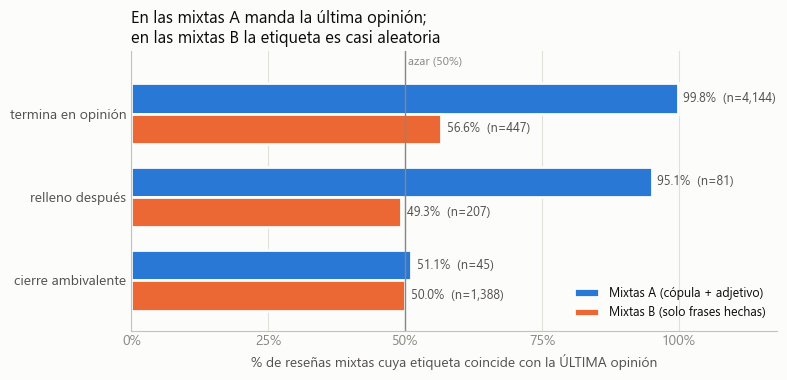

In [24]:
fig, ax = plt.subplots(figsize=(8, 3.9))
alto = 0.36
for k, (grupo, color, nombre) in enumerate([(GRUPOS[2], AZUL, 'Mixtas A (cópula + adjetivo)'),
                                            (GRUPOS[3], NARANJA, 'Mixtas B (solo frases hechas)')]):
    for i, final in enumerate(FINALES):
        if (grupo, final) not in tabla_familias.index:
            continue
        acierto, n = tabla_familias.loc[(grupo, final), 'regla_ultima_opinion'], int(tabla_familias.loc[(grupo, final), 'n'])
        yy = len(FINALES) - 1 - i + (alto / 2 if k == 0 else -alto / 2)
        ax.barh(yy, 100 * acierto, height=alto, color=color, edgecolor=SUPERFICIE, linewidth=2,
                label=nombre if i == 0 else None)
        ax.text(100 * acierto + 1, yy, f'{100 * acierto:.1f}%  (n={n:,})', va='center', fontsize=9, color=TINTA2)
ax.axvline(50, color=TENUE, linewidth=1)
ax.set_ylim(-0.6, len(FINALES) - 0.25)
ax.text(50.6, len(FINALES) - 0.42, 'azar (50%)', color=TENUE, fontsize=8.5)
ax.set_yticks(range(len(FINALES)), FINALES[::-1])
ax.set_xlim(0, 118); ax.set_xticks([0, 25, 50, 75, 100], ['0%', '25%', '50%', '75%', '100%'])
ax.xaxis.grid(True); ax.set_axisbelow(True); ax.tick_params(length=0)
ax.set_xlabel('% de reseñas mixtas cuya etiqueta coincide con la ÚLTIMA opinión')
ax.set_title('En las mixtas A manda la última opinión;\nen las mixtas B la etiqueta es casi aleatoria', color=TINTA)
ax.legend(loc='lower right', frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

**Lo que muestra la tabla**
- **Mixtas A** (al menos una opinión de cópula + adjetivo): si la reseña termina en opinión, la etiqueta es la de la **última opinión** en el 99.8 % de los casos (n = 4144), **sea cual sea el conector**. Es una regla determinista.
- **Mixtas B** (solo frases hechas): la última opinión coincide con la etiqueta solo en el 51.4 % de las 2042 reseñas, el 17.0 % de `train`. Durante la exploración buscamos cualquier otra señal en este grupo: orden, intensidad, posición, aspecto, concordancia, identidad del cierre, TF-IDF entrenado solo dentro del grupo. Usamos pruebas de permutación y corrección por comparaciones múltiples, y todo dio entre 47 % y 52 %: **la etiqueta de una mixta B es ruido irreducible**.
- Esto reinterpreta la sección 5: los conectores aditivos y *"eso sí"* parecían "aleatorios" porque mezclan reseñas A (deterministas) con reseñas B (aleatorias).

**Consecuencias**
1. **Techo de accuracy.** Si ~17 % de las reseñas se acierta al ~50 %, el error mínimo esperable ronda el 8–8.5 %: el techo práctico en validación cruzada está en **~0.915–0.92**. El ensemble v1 ya concentra en las mixtas B el 86 % de sus errores.
2. **Margen recuperable.** Fuera de B quedan errores en celdas deterministas, por ejemplo opiniones seguidas de relleno o reseñas con typos. Los dos componentes siguientes atacan esa parte.

## 10. Componente nuevo 1: `estructural` (parser de plantillas + HistGradientBoosting)
**Qué hace.** El transformador `Estructura` aplica el corrector de typos y el parser de la sección 9 a cada reseña y la resume en **59 rasgos numéricos "firmados"** (+1 / −1 / 0 según la polaridad de la opinión involucrada). Los rasgos describen:
- cuántas opiniones hay, de qué plantilla (A o B) y de qué signo; el signo de la primera, la última y la mayoritaria;
- si la reseña es coherente o mixta, y el signo de la última opinión **separado por plantilla** (`signo_mixta_A`, `signo_mixta_B`);
- el conector del último cambio de signo (tipo y conector concreto), multiplicado por el signo de la última opinión;
- cómo termina la reseña (en opinión, con relleno o con cierre ambivalente) y la posición de la última opinión.

Un **HistGradientBoostingClassifier** (lr 0.05, 200 iteraciones, 15 hojas, `min_samples_leaf=20`, sin *early stopping*) aprende sobre ellos reglas como *"mixta A que termina en opinión → signo de la última"*.

**Por qué funciona.** Los modelos de n-gramas aproximan estas reglas, pero fallan en celdas que son deterministas para el parser: una única opinión seguida de oraciones de relleno, mixtas A con relleno al final, typos dentro de la opinión. El componente estructural no sabe nada de las palabras fuera del inventario y sus errores son distintos a los de los n-gramas: por eso combina bien con ellos.

**Cómo se evita la fuga.** Todo lo que se aprende de los datos se ajusta en `fit`, es decir, **solo con el fold de entrenamiento** dentro de `cross_val_predict`:
- el **corrector de typos** (frecuencias de palabras de los textos de entrenamiento);
- la **polaridad de cada clave de opinión**. En la práctica es el léxico escrito a mano (prefijos `p_` / `n_` de las frases hechas, adjetivos positivos y negativos, negaciones), contrastado con la mayoría de etiquetas de las reseñas de entrenamiento del fold que tienen una sola opinión (claves con al menos 3 apariciones). En los 10 folds de las dos particiones esa mayoría coincide con el léxico en **todas** las claves (sección 13), así que los rasgos, y por tanto las OOF, son los mismos que con el léxico puro: este paso no introduce información de las etiquetas;
- el HistGradientBoosting.

El estimador recibe texto crudo, es clonable (sus parámetros están en `__init__`) y acepta la `y` codificada como 0/1/2 que entregan `cross_val_predict` y `VotingClassifier`.

**Sesgo de diseño.** El inventario, los 35 rasgos de interacción (conector × signo, final × signo…) y la versión final del componente se diseñaron mirando todo `train`: tablas por celda con etiquetas y errores OOF del ensemble v1 con la partición 42. La versión final se eligió entre unas 9 variantes comparándolas con las particiones 42 y 2024. La sección 13 cuantifica cuánto puede inflar eso la ganancia.

In [25]:
CONECTORES_ID = ['eso si', 'aun asi', 'al final', 'con todo', 'pero', 'a fin de cuentas', 'por otro lado', 'de paso',
                 'por cierto', 'ademas', 'ahora', 'y', '', 'lo que si', 'aunque', 'sin embargo', 'pero al final', 'igual',
                 'en cambio', 'ahora bien', 'aun con eso']
RASGOS_FINAL = ['relleno_tras', 'cierre', 'cierre_en_linea', 'fin_opinion', 'fin_relleno', 'fin_cierre',
                'signo_ultima_fin_opinion', 'signo_ultima_fin_relleno', 'signo_ultima_fin_cierre', 'posicion_ultima',
                'signo_eso_si_cola', 'signo_fuerte_alguno']


def rasgos_estructurales(p, signo=signo_semantico):
    # Resume el análisis de una reseña en un diccionario de rasgos numéricos (siempre las mismas claves y orden)
    ops, S = p['opiniones'], p['oraciones']
    f = {}
    n = len(ops)
    sg = [signo(o['clave']) for o in ops]
    f['sin_opiniones'] = float(n == 0)
    f['n_opiniones'] = n
    f['n_positivas'] = sum(s == 1 for s in sg)
    f['n_negativas'] = sum(s == -1 for s in sg)
    f['n_adjetivales'] = sum(es_adjetival(o) for o in ops)
    f['n_frases_hechas'] = n - f['n_adjetivales']
    f['signo_mayoria'] = float(np.sign(f['n_positivas'] - f['n_negativas']))
    s_pri = sg[0] if n else 0
    s_ult = sg[-1] if n else 0
    f['signo_primera'] = s_pri
    f['signo_ultima'] = s_ult
    coherente = n > 0 and len(set(sg)) == 1
    mixta = len(set(sg)) == 2
    f['coherente'] = float(coherente)
    f['signo_coherente'] = s_ult if coherente else 0
    f['mixta'] = float(mixta)
    adj = [s for s, o in zip(sg, ops) if es_adjetival(o)]
    fij = [s for s, o in zip(sg, ops) if not es_adjetival(o)]
    f['signo_ultima_adj'] = adj[-1] if adj else 0
    f['signo_primera_adj'] = adj[0] if adj else 0
    f['signo_ultima_frase'] = fij[-1] if fij else 0
    f['signo_mixta_A'] = s_ult if (mixta and adj) else 0
    f['signo_mixta_B'] = s_ult if (mixta and not adj) else 0
    # conector del último cambio de signo (o el de la última opinión si no hay cambio)
    jc = [j for j in range(1, n) if sg[j] != sg[j - 1]][-1] if mixta else n - 1
    con = ops[jc]['conector'] if n else ''
    tipo = ops[jc]['tipo_conector'] if n else 'ninguno'
    for t in ['fuerte', 'debil', 'aditivo', 'ninguno']:
        f['tipo_conector=' + t] = float(tipo == t)
        f['signo_con_' + t] = s_ult if (tipo == t and mixta) else 0
    for c in CONECTORES_ID:
        f['signo_con=' + (c or 'NADA')] = s_ult if (con == c and mixta) else 0
    # cómo termina la reseña
    if n:
        ult = ops[-1]
        hay_cierre = bool(p['cierre'] or p['cierre_en_linea'])
        relleno = len(S) - 1 - ult['oracion'] - (1 if p['oracion_cierre'] > ult['oracion'] else 0)
        f['relleno_tras'] = relleno
        f['cierre'] = float(bool(p['cierre']))
        f['cierre_en_linea'] = float(bool(p['cierre_en_linea']))
        f['fin_opinion'] = float(not hay_cierre and relleno == 0)
        f['fin_relleno'] = float(not hay_cierre and relleno > 0)
        f['fin_cierre'] = float(hay_cierre)
        f['signo_ultima_fin_opinion'] = s_ult * f['fin_opinion']
        f['signo_ultima_fin_relleno'] = s_ult * f['fin_relleno']
        f['signo_ultima_fin_cierre'] = s_ult * f['fin_cierre']
        f['posicion_ultima'] = ult['oracion'] / max(1, len(S) - 1)
        cola = ult['despues'] + ' ' + ult['posterior']
        f['signo_eso_si_cola'] = s_ult * float(bool(re.search(r'\beso si\b', cola)))
        f['signo_fuerte_alguno'] = s_ult * float(any(o['tipo_conector'] == 'fuerte' for o in ops[1:]))
    else:
        for k in RASGOS_FINAL:
            f[k] = 0.0
    f['n_oraciones'] = len(S)
    return f


_CODIGO_CLASE = {c: i for i, c in enumerate(CLASES)}   # y codificada 0/1/2 en orden alfabético, como la entregan
                                                        # cross_val_predict y VotingClassifier


def _es_clase(v, clase):   # acepta etiquetas de texto o codificadas
    return v == clase if isinstance(v, str) else int(v) == _CODIGO_CLASE[clase]


class Estructura(TransformerMixin, BaseEstimator):
    # Texto crudo -> DataFrame de rasgos estructurales. fit() ajusta el corrector de typos y, con
    # modo_polaridad='en_fold', la polaridad de cada clave de opinión, usando solo los datos que recibe.
    def __init__(self, frec_min=5, modo_polaridad='en_fold', min_apariciones=3):
        self.frec_min = frec_min
        self.modo_polaridad = modo_polaridad
        self.min_apariciones = min_apariciones

    def fit(self, X, y=None):
        self.corrector_ = CorrectorTypos(self.frec_min).ajustar([normalizar(t) for t in X])
        self.lexico_ = {}
        if self.modo_polaridad == 'en_fold':
            conteo = {}                                   # clave -> [n negativas, n positivas]
            for p, v in zip(self.analizar(X), y):
                if len(p['opiniones']) != 1 or not (_es_clase(v, 'positivo') or _es_clase(v, 'negativo')):
                    continue
                conteo.setdefault(p['opiniones'][0]['clave'], [0, 0])[int(_es_clase(v, 'positivo'))] += 1
            self.lexico_ = {k: (1 if pos > neg else -1) for k, (neg, pos) in conteo.items()
                            if neg + pos >= self.min_apariciones}
        return self

    def signo(self, clave):
        return self.lexico_.get(clave, signo_semantico(clave))

    def analizar(self, X):
        return [analizar_resena(self.corrector_.corregir(normalizar(t))) for t in X]

    def transform(self, X):
        return pd.DataFrame([rasgos_estructurales(p, self.signo) for p in self.analizar(X)]).astype(float)


def modelo_estructural():
    return Pipeline([('estructura', Estructura(modo_polaridad='en_fold')),
                     ('hgb', HistGradientBoostingClassifier(learning_rate=0.05, max_iter=200, max_leaf_nodes=15,
                                                            min_samples_leaf=20, early_stopping=False, random_state=0))])


print('Rasgos estructurales por reseña:', len(rasgos_estructurales(analizar_resena(''))))

Rasgos estructurales por reseña: 59


In [26]:
# Ejemplo: rasgos no nulos de la reseña mixta A mostrada en la sección 9 (Estructura ajustada aquí con todo train
# solo para ilustrar; en la evaluación se ajusta dentro de cada fold)
i_ejemplo = int(np.flatnonzero((CELDAS.grupo == GRUPOS[2]) & (CELDAS.final == FINALES[0]) & (train.text.str.len() < 330))[0])
estructura_ilustrativa = Estructura().fit(X, y)
rasgos_ejemplo = estructura_ilustrativa.transform([X[i_ejemplo]]).T[0]
discrepancias = sum(v != signo_semantico(k) for k, v in estructura_ilustrativa.lexico_.items())
print(f'{len(rasgos_ejemplo)} rasgos por reseña; claves con polaridad aprendida: {len(estructura_ilustrativa.lexico_)}, '
      f'de las cuales {discrepancias} difieren de la polaridad semántica del inventario')
print('El estimador es clonable:', clone(modelo_estructural()).get_params()['estructura'])
rasgos_ejemplo[rasgos_ejemplo != 0].to_frame('valor')

59 rasgos por reseña; claves con polaridad aprendida: 114, de las cuales 0 difieren de la polaridad semántica del inventario
El estimador es clonable: Estructura()


,valor
n_opiniones,2.0
n_positivas,1.0
n_negativas,1.0
n_adjetivales,2.0
signo_primera,-1.0
signo_ultima,1.0
mixta,1.0
signo_ultima_adj,1.0
signo_primera_adj,-1.0
signo_mixta_A,1.0


In [27]:
oof_nuevo, seg = calcular_oof({'estructural': modelo_estructural}, CV)
OOF.update(oof_nuevo); SEGUNDOS.update(seg)
RESUMEN['acc_estructural'] = accuracy_score(y, CLASES[OOF['estructural'].argmax(1)])

estructural  accuracy OOF = 0.9075   (42 s)


## 11. Componente nuevo 2: `stk_nb6_anc` (stacking de NB-LR sobre bloques anclados en las opiniones)
**NB-LR** (Wang y Manning, 2012) es una regresión logística sobre rasgos de bolsa de palabras **binarios escalados por la razón de log-conteos** de Naive Bayes. Para cada clase $c$ (uno contra el resto), con $x \in \{0,1\}^V$ la presencia de cada n-grama:

$$p_c = \alpha + \sum_{i:\,y_i=c} x_i, \qquad q_c = \alpha + \sum_{i:\,y_i\neq c} x_i, \qquad r_c = \log\frac{p_c / \lVert p_c\rVert_1}{q_c / \lVert q_c\rVert_1}$$

y se entrena una regresión logística sobre $x \odot r_c$ (aquí $\alpha = 1$, $C = 0.25$, n-gramas de palabras 1-2). El escalado NB actúa como un *prior* sobre la relevancia de cada palabra: los n-gramas discriminativos llegan con peso grande antes de la regularización. Eso ayuda en bloques cortos y con pocos ejemplos, como `post_fuerte` o la cláusula de la última opinión. Las probabilidades de las 3 regresiones se normalizan para que sumen 1.

**Bloques anclados en las opiniones.** A los 6 bloques de la sección 6 se suman 4 que dependen de **dónde están las opiniones**:

| Bloque | Contenido |
|---|---|
| `op_pri` | primera cláusula con opinión |
| `op_ult` | última cláusula con opinión |
| `cl_fuerte` | la cláusula exacta que sigue al último conector fuerte |
| `ult_no_cierre` | la última oración con opinión que **no** es un cierre ambivalente |

Las cláusulas con opinión las marca un **detector**: una regresión logística (TF-IDF 1-2) entrenada para distinguir reseñas neutrales de polares y aplicada a cada cláusula, que marca opinión si su puntuación supera 3. En la **versión suave**, si ninguna cláusula supera el umbral se toma la de mayor puntuación, para que el bloque nunca quede vacío.

**Stacking.** Un NB-LR por bloque (10 modelos base) y el mismo meta-clasificador HistGradientBoosting del stacking v1, con `StackingClassifier(cv=5)`.

**De dónde viene la ganancia.** En la exploración (partición 42), el mismo stacking con regresión logística TF-IDF por bloque quedó en 0.898, como el stacking v1 en esa ejecución, y con NB-LR en los mismos 6 bloques subió a 0.908: la ganancia del componente viene sobre todo de la **representación NB**. Los bloques anclados añadieron 0.34 puntos de accuracy con la partición 42, pero solo 0.14 con la 2024, del mismo orden que la variación por semillas internas (±0.2–0.3 puntos). Dentro del ensemble no superan de forma consistente al mismo stacking sin anclar (sección 18).

**Cómo se evita la fuga.** Vocabularios, razones NB, detector de opinión y meta-modelo se ajustan solo con el fold de entrenamiento. Además, el detector **se aplica a las reseñas de entrenamiento con *cross-fitting* interno**: los bloques anclados de cada reseña de entrenamiento se calculan con un detector entrenado en los otros 4/5 de ese fold. Sin esto, el detector casi no se equivoca sobre sus propias reseñas de entrenamiento y el modelo aprende que *"bloque de opinión vacío → neutral"*; en la exploración, la categoría "sin opinión detectada" de las reseñas de validación (donde el detector sí falla) se desplomaba entonces a ~30 % de acierto. Con *cross-fitting*, el detector se equivoca igual en entrenamiento que en validación. Para predecir se usa el detector entrenado con todo el fold.

**Selección de la configuración (sesgo).** La configuración final fue la mejor de unas 37 variantes evaluadas con la partición 42: umbral 3, $C = 0.25$, *cross-fitting*, versión suave, el léxico de 15 cierres ambivalentes y 4 bloques anclados elegidos entre 6 candidatos. $C = 0.25$ se eligió con una validación interna en el `train` del primer fold de esa partición. Es una fuga leve de selección, de efecto despreciable: eligiendo $C$ dentro de cada ajuste, el stacking NB-LR sin anclar pasa de 0.9079 a 0.9073. Como componente extra del v1, esta configuración ganaba +0.86 puntos con la partición 42. Una auditoría posterior, con otras semillas internas y con la partición 2024, estima su aporte sin ese sesgo de selección en **≈ +0.4 puntos** (entre +0.29 y +0.48). Las semillas internas (*cross-fitting* 11, CV del stacking 1, HistGradientBoosting 0) están fijas para que el resultado sea reproducible; cambiarlas mueve la accuracy del componente ±0.2–0.3 puntos.

In [28]:
# ---------------------------------------------------------------- NB-LR (uno contra el resto)
class NBLR(ClassifierMixin, BaseEstimator):
    # Regresión logística sobre rasgos binarios escalados por la razón de log-conteos r_c de Naive Bayes
    def __init__(self, C=0.25, alpha=1.0):
        self.C = C
        self.alpha = alpha

    @staticmethod
    def _binarizar(X):
        X = sp.csr_matrix(X, dtype=np.float64).copy()
        X.data = (X.data > 0).astype(np.float64)
        return X

    def fit(self, X, y):
        X, y = self._binarizar(X), np.asarray(y)
        self.classes_ = np.unique(y)
        self.r_, self.lr_ = [], []
        for c in self.classes_:
            m = y == c
            p = self.alpha + np.asarray(X[m].sum(0)).ravel()
            q = self.alpha + np.asarray(X[~m].sum(0)).ravel()
            r = np.log((p / p.sum()) / (q / q.sum()))
            self.r_.append(r)
            self.lr_.append(LogisticRegression(C=self.C, solver='liblinear', max_iter=2000).fit(X @ sp.diags(r), m))
        return self

    def decision_function(self, X):
        X = self._binarizar(X)
        return np.column_stack([lr.decision_function(X @ sp.diags(r)) for r, lr in zip(self.r_, self.lr_)])

    def predict_proba(self, X):
        P = 1.0 / (1.0 + np.exp(-self.decision_function(X)))
        return P / P.sum(1, keepdims=True)

    def predict(self, X):
        return self.classes_[self.decision_function(X).argmax(1)]


print('NBLR es clonable:', clone(NBLR()).get_params())

NBLR es clonable: {'C': 0.25, 'alpha': 1.0}


In [29]:
# ---------------------------------------------------------------- bloques anclados en las opiniones
RE_CORTE_CLAUSULA = re.compile(r',\s*(?=(?:pero|aunque|y|eso si|en cambio|sin embargo|mientras que|aun asi|por otro lado|'
                               r'ademas|de paso|por cierto|igual|total|en fin|al final|con todo|a fin de cuentas|'
                               r'de todos modos|de todas formas|no obstante|lo que si|ahora bien)\b)|;\s*')
RE_AMBIVALENTE = re.compile(r'ni tan bueno ni tan malo|ni lo mejor ni lo peor|sentimientos encontrados|no sabria (bien )?que '
                            r'recomendar|sigo con dudas|cada quien|a criterio|sopesalo|para gustos|hay de todo|ahi lo dejo|'
                            r'no me decido|ahi queda|sigo dandole vueltas|dudando')


def clausulas_con_oracion(t):
    # [(texto de la cláusula, índice de su oración)] de un texto normalizado
    return [(c.strip(), i) for i, s in enumerate(oraciones(t)) for c in RE_CORTE_CLAUSULA.split(s) if c.strip()]


def empieza_con_conector_fuerte(clausula):
    # ¿La cláusula empieza con un conector adversativo fuerte (pero, aun así, aunque...)? RE_FUERTE: sección 6
    return RE_FUERTE.match(clausula) is not None


class BloquesAnclados(TransformerMixin, BaseEstimator):
    # Texto crudo -> DataFrame con los 6 bloques de Bloques + op_pri, op_ult, cl_fuerte y ult_no_cierre.
    # fit() entrena el detector de opinión; fit_transform() calcula los bloques de las reseñas de entrenamiento
    # con detectores entrenados fuera de cada parte (cross-fitting con folds_internos partes).
    def __init__(self, umbral=3.0, folds_internos=5, suave=True, clase_neutral='neutral'):
        self.umbral = umbral
        self.folds_internos = folds_internos
        self.suave = suave
        self.clase_neutral = clase_neutral

    def fit(self, X, y):
        y = np.asarray(y)
        # y llega como texto o codificada 0/1/2 en el orden de CLASES (cross_val_predict, StackingClassifier, Voting)
        neutral = self.clase_neutral if y.dtype.kind in 'OUS' else int(np.searchsorted(CLASES, self.clase_neutral))
        polar = y != neutral
        assert len(np.unique(y)) == len(CLASES) and 0.6 < polar.mean() < 0.8, \
            f'codificación de y inesperada: clases {np.unique(y)}, fracción de reseñas polares {polar.mean():.2f}'
        T = [normalizar(t) for t in X]
        self.vectorizador_ = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, min_df=2)
        self.detector_ = LogisticRegression(C=5, max_iter=5000).fit(self.vectorizador_.fit_transform(T), polar)
        return self

    def fit_transform(self, X, y=None, **kwargs):
        self.fit(X, y)
        if not self.folds_internos:
            return self.transform(X)
        X, y = np.asarray(X, dtype=object), np.asarray(y)
        partes = []
        for a, b in StratifiedKFold(self.folds_internos, shuffle=True, random_state=11).split(X, y):
            detector_parcial = BloquesAnclados(umbral=self.umbral, folds_internos=0, suave=self.suave,
                                               clase_neutral=self.clase_neutral).fit(X[a], y[a])
            D = detector_parcial.transform(X[b])
            D.index = b
            partes.append(D)
        return pd.concat(partes).sort_index().reset_index(drop=True)

    def transform(self, X):
        T = [normalizar(t) for t in X]
        D = Bloques().transform(X)
        CL = [clausulas_con_oracion(t) for t in T]
        planas = [c for cc in CL for c, _ in cc]
        # puntuación de opinión de cada cláusula (sin el intercepto, que solo refleja la proporción de clases)
        puntaje = self.detector_.decision_function(self.vectorizador_.transform(planas)) - self.detector_.intercept_[0]
        cl_fuerte, op_pri, op_ult, ult_no_cierre = [], [], [], []
        k = 0
        for t, cc in zip(T, CL):
            o = puntaje[k:k + len(cc)]
            k += len(cc)
            textos = [c for c, _ in cc]
            con_opinion = [i for i in range(len(cc)) if o[i] > self.umbral]
            if self.suave and not con_opinion and len(cc):
                con_opinion = [int(np.argmax(o))]
            fuertes = [i for i, c in enumerate(textos) if empieza_con_conector_fuerte(c)]
            cl_fuerte.append(textos[fuertes[-1]] if fuertes else '')
            op_pri.append(textos[con_opinion[0]] if con_opinion else '')
            op_ult.append(textos[con_opinion[-1]] if con_opinion else '')
            ss = oraciones(t)
            oraciones_opinion = sorted({cc[i][1] for i in con_opinion})
            candidatas = [j for j in oraciones_opinion if not RE_AMBIVALENTE.search(ss[j])]
            ult_no_cierre.append(ss[candidatas[-1]] if candidatas else '')
        D['op_pri'], D['op_ult'], D['cl_fuerte'], D['ult_no_cierre'] = op_pri, op_ult, cl_fuerte, ult_no_cierre
        return D


BLOQUES_NBLR = BLOQUES_STACKING + ['op_pri', 'op_ult', 'cl_fuerte', 'ult_no_cierre']


def modelo_stk_nb6_anc():
    por_bloque = [(b, Pipeline([('vec', ColumnTransformer([('palabras', CountVectorizer(ngram_range=(1, 2), binary=True,
                                                                                         min_df=2), b)])),
                                ('clf', NBLR(C=0.25))]))
                  for b in BLOQUES_NBLR]
    meta = HistGradientBoostingClassifier(learning_rate=0.05, max_iter=300, max_leaf_nodes=15, min_samples_leaf=40,
                                          early_stopping=False, random_state=0)
    return Pipeline([('bloques', BloquesAnclados(umbral=3.0, folds_internos=5, suave=True)),
                     ('stack', StackingClassifier(por_bloque, final_estimator=meta, stack_method='predict_proba',
                                                  cv=StratifiedKFold(5, shuffle=True, random_state=1)))])


print(f'{len(BLOQUES_NBLR)} bloques en el stacking NB-LR:', ', '.join(BLOQUES_NBLR))

10 bloques en el stacking NB-LR: completo, post, post_fuerte, post_debil, ultima, penultima, op_pri, op_ult, cl_fuerte, ult_no_cierre


In [30]:
# Ejemplo: los 4 bloques anclados de la reseña mixta B de la sección 9 (detector entrenado aquí con todo train solo
# para ilustrar; en la evaluación se entrena dentro de cada fold)
i_ejemplo_b = int(np.flatnonzero((CELDAS.grupo == GRUPOS[3]) & (CELDAS.final == FINALES[0]) & (train.text.str.len() < 330))[0])
print(X[i_ejemplo_b], '\n')
BloquesAnclados(folds_internos=0).fit(X, y).transform([X[i_ejemplo_b]])[['op_pri', 'op_ult', 'cl_fuerte', 'ult_no_cierre']].T.rename(columns={0: 'contenido'})

Lo pedi a principios de mes y me llego en cuatro dias, en su caja normal de siempre. La verdad no pare de teenr problemas con el teclado desde que lo conecte en mi escritorio del cuarto. De paso, termine feliz con el ensamblaje, todo venia bien ajustado cuando lo revise. 



,contenido
op_pri,la verdad no pare de teenr problemas con el teclado desde que lo conecte en mi escritorio del cuarto.
op_ult,"de paso, termine feliz con el ensamblaje, todo venia bien ajustado cuando lo revise."
cl_fuerte,
ult_no_cierre,"de paso, termine feliz con el ensamblaje, todo venia bien ajustado cuando lo revise."


In [31]:
oof_nuevo, seg = calcular_oof({'stk_nb6_anc': modelo_stk_nb6_anc}, CV)
OOF.update(oof_nuevo); SEGUNDOS.update(seg)
RESUMEN['acc_stk_nb6_anc'] = accuracy_score(y, CLASES[OOF['stk_nb6_anc'].argmax(1)])

stk_nb6_anc  accuracy OOF = 0.9112   (96 s)


## 12. Ensemble v3a: pesos elegidos con dos particiones
Repetimos el procedimiento de la sección 8 con los 4 componentes del v1 más `estructural` y `stk_nb6_anc`, con un cambio. Con 6 componentes la rejilla tiene 3 003 combinaciones, y con una sola partición de la validación cruzada puede premiar combinaciones que solo funcionan en esa partición: los componentes con *stacking* cambian algunas décimas de un juego de folds a otro. Por eso:
1. calculamos las OOF de los 6 componentes también con la partición `random_state=2024`;
2. elegimos la combinación de pesos con la mayor **accuracy OOF media de las dos particiones**;
3. validamos esa regla de forma **anidada**: en cada una de 5 partes de las reseñas, los pesos se eligen con las otras 4/5 (en las dos particiones) y se mide la accuracy en la parte no vista, en cada partición;
4. comparamos con el v1, que elige sus pesos con el mismo procedimiento, mediante la **prueba exacta de McNemar** sobre los aciertos anidados (cada reseña se predice con pesos elegidos sin mirarla).

Primero comprobamos que el código de este notebook reproduce las accuracies OOF que obtuvieron los scripts de desarrollo con las mismas particiones.

In [32]:
NOMBRES = list(FABRICAS_V1) + ['estructural', 'stk_nb6_anc']
FABRICAS = {**FABRICAS_V1, 'estructural': modelo_estructural, 'stk_nb6_anc': modelo_stk_nb6_anc}
CV_2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED_2)
OOF_2, SEGUNDOS_2 = calcular_oof(FABRICAS, CV_2, prefijo=f'[{SEED_2}] ')
OOF_PARTICION = {SEED: OOF, SEED_2: OOF_2}
for n in NOMBRES:
    RESUMEN[f'acc_{n}_{SEED_2}'] = accuracy_score(y, CLASES[OOF_2[n].argmax(1)])

# Accuracy OOF obtenida con los scripts de desarrollo, con las mismas dos particiones
REFERENCIA_DESARROLLO = {
    SEED: {'stacking': 0.8983, 'lr_palabras': 0.8951, 'lr_pal_car': 0.8981, 'svc_pal_car': 0.8998,
           'estructural': 0.9075, 'stk_nb6_anc': 0.9113},
    SEED_2: {'stacking': 0.9013, 'lr_palabras': 0.8939, 'lr_pal_car': 0.8962, 'svc_pal_car': 0.8998,
             'estructural': 0.9096, 'stk_nb6_anc': 0.9094}}
componentes = pd.DataFrame(index=NOMBRES)
for p in PARTICIONES:
    componentes[f'oof_{p}'] = [accuracy_score(y, CLASES[OOF_PARTICION[p][n].argmax(1)]) for n in NOMBRES]
    componentes[f'desarrollo_{p}'] = [REFERENCIA_DESARROLLO[p][n] for n in NOMBRES]
    componentes[f'diferencia_{p} (pts)'] = 100 * (componentes[f'oof_{p}'] - componentes[f'desarrollo_{p}'])
componentes['segundos (dos particiones)'] = [SEGUNDOS[n] + SEGUNDOS_2[n] for n in NOMBRES]
display(componentes.round({**{f'{c}_{p}': 4 for p in PARTICIONES for c in ('oof', 'desarrollo')},
                           **{f'diferencia_{p} (pts)': 2 for p in PARTICIONES}, 'segundos (dos particiones)': 0}))

aciertos_modelos = pd.DataFrame({n: CLASES[OOF[n].argmax(1)] == y for n in NOMBRES})
print(f'Correlación de aciertos entre componentes (partición {SEED}):')
display(aciertos_modelos.corr().round(2))

[2024] stacking     accuracy OOF = 0.9004   (309 s)


[2024] lr_palabras  accuracy OOF = 0.8939   (9 s)


[2024] lr_pal_car   accuracy OOF = 0.8962   (46 s)


[2024] svc_pal_car  accuracy OOF = 0.8998   (40 s)


[2024] estructural  accuracy OOF = 0.9096   (41 s)


[2024] stk_nb6_anc  accuracy OOF = 0.9094   (72 s)


,oof_42,desarrollo_42,diferencia_42 (pts),oof_2024,desarrollo_2024,diferencia_2024 (pts),segundos (dos particiones)
stacking,0.9012,0.8983,0.29,0.9004,0.9013,-0.09,584.0
lr_palabras,0.8951,0.8951,-0.00,0.8939,0.8939,0.00,21.0
lr_pal_car,0.8981,0.8981,-0.00,0.8962,0.8962,0.00,94.0
svc_pal_car,0.8998,0.8998,-0.00,0.8998,0.8998,-0.00,85.0
estructural,0.9075,0.9075,0.00,0.9096,0.9096,-0.00,83.0
stk_nb6_anc,0.9112,0.9113,-0.01,0.9094,0.9094,0.00,168.0


Correlación de aciertos entre componentes (partición 42):


,stacking,lr_palabras,lr_pal_car,svc_pal_car,estructural,stk_nb6_anc
stacking,1.00,0.54,0.56,0.56,0.47,0.51
lr_palabras,0.54,1.00,0.82,0.82,0.42,0.46
lr_pal_car,0.56,0.82,1.00,0.86,0.44,0.47
svc_pal_car,0.56,0.82,0.86,1.00,0.46,0.48
estructural,0.47,0.42,0.44,0.46,1.00,0.49
stk_nb6_anc,0.51,0.46,0.47,0.48,0.49,1.00


**Reproducibilidad de los componentes.** Las regresiones logísticas, el SVM y el componente `estructural` reproducen las cifras de desarrollo en las dos particiones (las cifras de desarrollo están redondeadas a 4 decimales). Los dos *stacking* pueden diferir algunas décimas de punto. Sus meta-modelos HistGradientBoosting amplifican diferencias numéricas minúsculas en sus entradas (~1e-7 en las probabilidades de las regresiones logísticas), que dependen del número de hilos de BLAS con que se ejecuta cada proceso. Lo comprobamos ejecutando fuera del notebook el código original de desarrollo con la partición 42:
- con la misma configuración de hilos que este notebook (4 de OpenMP y 4 de BLAS por proceso), el código original reproduce **exactamente** las OOF de `stacking` (0.9012) y `stk_nb6_anc` (0.9112) de este notebook, con 0 predicciones distintas;
- con la configuración de los scripts de desarrollo (4 de OpenMP y 6 de BLAS), el mismo código recupera exactamente el 0.8983 del stacking.

La diferencia, por tanto, no viene del código, y la del stacking con la partición 2024 (0.9004 frente a 0.9013) tiene el mismo origen. Las 352 predicciones del stacking que cambian entre una configuración y otra con la partición 42 son en un 82 % mixtas B, donde el modelo está en torno al 50 %. Es una medida útil del ruido de la evaluación: diferencias menores que ~0.3 puntos entre variantes no deben tomarse como mejoras reales, y es otro motivo para no elegir los pesos con una sola partición.

In [33]:
REJILLAS = {}      # conjunto de componentes -> (pesos de la rejilla, [matriz de aciertos de cada partición])


def rejilla(nombres):
    clave = tuple(nombres)
    if clave not in REJILLAS:
        resultados = [evaluar_rejilla(OOF_PARTICION[p], nombres) for p in PARTICIONES]
        REJILLAS[clave] = (resultados[0][0], [ac for _, ac in resultados])
    return REJILLAS[clave]


def elegir_pesos(nombres, particiones=(0, 1)):
    # Combinación con la mayor accuracy OOF media en las particiones indicadas (en empate, la primera de la rejilla).
    # Devuelve los pesos y la accuracy OOF que logran en cada partición.
    W, ac = rejilla(nombres)
    j = int(np.argmax(np.mean([ac[k].mean(1) for k in particiones], axis=0)))
    return {n: float(w) for n, w in zip(nombres, W[j])}, [float(a[j].mean()) for a in ac]


ETIQUETAS = [str(p) for p in PARTICIONES]
t0 = time.time()
W_v3a, ACIERTOS_V3A = rejilla(NOMBRES)
print(f'{len(W_v3a)} combinaciones evaluadas en cada partición ({time.time() - t0:.0f} s). '
      'Las 10 mejores según la accuracy OOF media de las dos particiones:')
display(mejores_pesos(W_v3a, ACIERTOS_V3A, NOMBRES, etiquetas=ETIQUETAS))

filas = {}
for criterio, k in {f'solo partición {SEED}': (0,), f'solo partición {SEED_2}': (1,),
                    'media de las dos (pesos finales)': (0, 1)}.items():
    pesos_k, accs_k = elegir_pesos(NOMBRES, k)
    filas[criterio] = {**pesos_k, **{f'accuracy OOF {e}': a for e, a in zip(ETIQUETAS, accs_k)}}
print('Pesos óptimos según las particiones con que se eligen, y su accuracy OOF en cada partición:')
display(pd.DataFrame(filas).T.round(4))

anidado_v3a, ANIDADO_V3A = seleccion_anidada(W_v3a, ACIERTOS_V3A, NOMBRES, etiquetas=ETIQUETAS)
print('Validación anidada: pesos elegidos con 4/5 de las reseñas (media de las dos particiones), accuracy en el 1/5 restante:')
display(anidado_v3a)

PESOS, oof_v3a = elegir_pesos(NOMBRES)
PESOS_V1_2P, oof_v1 = elegir_pesos(NOMBRES_V1)
_, ANIDADO_V1 = seleccion_anidada(*rejilla(NOMBRES_V1), NOMBRES_V1, etiquetas=ETIQUETAS)
pred_v3a = CLASES[prob_ensemble(OOF, PESOS).argmax(1)]
pruebas = [mcnemar(ANIDADO_V3A[k], ANIDADO_V1[k]) for k in range(len(PARTICIONES))]
comparacion = pd.DataFrame([[*oof_v1, *ANIDADO_V1.mean(1)], [*oof_v3a, *ANIDADO_V3A.mean(1)]],
                           index=['ensemble v1 (4 componentes)', 'ensemble v3a (6 componentes)'],
                           columns=[f'accuracy OOF {e}' for e in ETIQUETAS] + [f'accuracy anidada {e}' for e in ETIQUETAS])
comparacion['pesos (media de las dos particiones)'] = [', '.join(f'{n} {w:.1f}' for n, w in P.items() if w > 0)
                                                       for P in (PESOS_V1_2P, PESOS)]
print('Comparación con el v1, que elige sus pesos con el mismo procedimiento:')
display(comparacion.round(4))

RESUMEN['pesos'] = ', '.join(f'{n} {w:.1f}' for n, w in PESOS.items())
RESUMEN['pesos_v1_2p'] = ', '.join(f'{n} {w:.1f}' for n, w in PESOS_V1_2P.items() if w > 0)
RESUMEN['v1_2p_oof'], RESUMEN['v1_2p_oof_2024'] = oof_v1
RESUMEN['v1_2p_anidado'], RESUMEN['v1_2p_anidado_2024'] = ANIDADO_V1.mean(1)
RESUMEN['v3a_oof'], RESUMEN['v3a_oof_2024'] = oof_v3a
RESUMEN['v3a_anidado'], RESUMEN['v3a_anidado_2024'] = ANIDADO_V3A.mean(1)
RESUMEN['delta_anidado_pts'] = 100 * (RESUMEN['v3a_anidado'] - RESUMEN['v1_2p_anidado'])
RESUMEN['delta_2024'] = 100 * (RESUMEN['v3a_anidado_2024'] - RESUMEN['v1_2p_anidado_2024'])
RESUMEN['delta_media'] = (RESUMEN['delta_anidado_pts'] + RESUMEN['delta_2024']) / 2
RESUMEN['v1_2p_anidado_media'], RESUMEN['v3a_anidado_media'] = ANIDADO_V1.mean(), ANIDADO_V3A.mean()
for sufijo, prueba in zip(['', '_2024'], pruebas):
    RESUMEN.update({f'mcnemar_gana{sufijo}': prueba['gana'], f'mcnemar_pierde{sufijo}': prueba['pierde'],
                    f'mcnemar_p{sufijo}': prueba['p']})
print('Pesos finales:', PESOS)
for k, p in enumerate(PARTICIONES):
    print(f'Partición {p}: v1 anidada {ANIDADO_V1[k].mean():.4f} | v3a anidada {ANIDADO_V3A[k].mean():.4f} '
          f'({100 * (ANIDADO_V3A[k].mean() - ANIDADO_V1[k].mean()):+.2f} puntos) | McNemar (aciertos anidados): el v3a '
          f'acierta {pruebas[k]["gana"]} reseñas que el v1 falla y falla {pruebas[k]["pierde"]} que el v1 acierta '
          f'(p = {pruebas[k]["p"]:.1e})')

3003 combinaciones evaluadas en cada partición (2 s). Las 10 mejores según la accuracy OOF media de las dos particiones:


,stacking,lr_palabras,lr_pal_car,svc_pal_car,estructural,stk_nb6_anc,accuracy_oof_42,accuracy_oof_2024,accuracy_oof_media
0,0.0,0.0,0.0,0.4,0.3,0.3,0.9183,0.9150,0.9167
1,0.1,0.1,0.0,0.2,0.3,0.3,0.9182,0.9151,0.9167
2,0.0,0.0,0.0,0.3,0.4,0.3,0.9178,0.9154,0.9166
3,0.1,0.1,0.2,0.0,0.3,0.3,0.9179,0.9153,0.9166
4,0.0,0.1,0.0,0.3,0.3,0.3,0.9182,0.9148,0.9165
5,0.0,0.2,0.0,0.2,0.3,0.3,0.9173,0.9158,0.9165
6,0.0,0.3,0.1,0.0,0.3,0.3,0.9160,0.9170,0.9165
7,0.0,0.0,0.0,0.4,0.4,0.2,0.9174,0.9153,0.9164
8,0.0,0.2,0.1,0.1,0.3,0.3,0.9168,0.9159,0.9164
9,0.0,0.0,0.1,0.3,0.3,0.3,0.9178,0.9148,0.9163


Pesos óptimos según las particiones con que se eligen, y su accuracy OOF en cada partición:


,stacking,lr_palabras,lr_pal_car,svc_pal_car,estructural,stk_nb6_anc,accuracy OOF 42,accuracy OOF 2024
solo partición 42,0.0,0.0,0.0,0.4,0.3,0.3,0.9183,0.915
solo partición 2024,0.0,0.3,0.1,0.0,0.3,0.3,0.9160,0.917
media de las dos (pesos finales),0.0,0.0,0.0,0.4,0.3,0.3,0.9183,0.915


Validación anidada: pesos elegidos con 4/5 de las reseñas (media de las dos particiones), accuracy en el 1/5 restante:


,stacking,lr_palabras,lr_pal_car,svc_pal_car,estructural,stk_nb6_anc,accuracy_no_vista_42,accuracy_no_vista_2024
0,0.0,0.3,0.1,0.0,0.3,0.3,0.9129,0.9146
1,0.0,0.0,0.0,0.4,0.3,0.3,0.9246,0.9158
2,0.0,0.0,0.0,0.4,0.3,0.3,0.9179,0.9129
3,0.0,0.0,0.0,0.3,0.4,0.3,0.9192,0.9142
4,0.0,0.0,0.0,0.4,0.3,0.3,0.9104,0.9096


Comparación con el v1, que elige sus pesos con el mismo procedimiento:


,accuracy OOF 42,accuracy OOF 2024,accuracy anidada 42,accuracy anidada 2024,pesos (media de las dos particiones)
ensemble v1 (4 componentes),0.9063,0.9068,0.9061,0.9055,"stacking 0.5, lr_palabras 0.5"
ensemble v3a (6 componentes),0.9183,0.9150,0.9170,0.9134,"svc_pal_car 0.4, estructural 0.3, stk_nb6_anc 0.3"


Pesos finales: {'stacking': 0.0, 'lr_palabras': 0.0, 'lr_pal_car': 0.0, 'svc_pal_car': 0.4, 'estructural': 0.3, 'stk_nb6_anc': 0.3}
Partición 42: v1 anidada 0.9061 | v3a anidada 0.9170 (+1.09 puntos) | McNemar (aciertos anidados): el v3a acierta 360 reseñas que el v1 falla y falla 229 que el v1 acierta (p = 7.5e-08)
Partición 2024: v1 anidada 0.9055 | v3a anidada 0.9134 (+0.79 puntos) | McNemar (aciertos anidados): el v3a acierta 338 reseñas que el v1 falla y falla 243 que el v1 acierta (p = 9.3e-05)


In [34]:
CELDAS['v1_anidado'], CELDAS['v3a_anidado'] = ANIDADO_V1[0], ANIDADO_V3A[0]
por_celda = CELDAS.groupby(['grupo', 'final'], sort=False).agg(
    n=('v1_anidado', 'size'), acc_v1=('v1_anidado', 'mean'), acc_v3a=('v3a_anidado', 'mean'),
    errores_v1=('v1_anidado', lambda s: int((~s).sum())), errores_v3a=('v3a_anidado', lambda s: int((~s).sum())))
por_celda = por_celda.reindex([(g, f) for g in GRUPOS for f in (['—'] if g == GRUPOS[0] else FINALES)]).dropna()
por_celda[['n', 'errores_v1', 'errores_v3a']] = por_celda[['n', 'errores_v1', 'errores_v3a']].astype(int)
por_celda['errores_recuperados'] = por_celda.errores_v1 - por_celda.errores_v3a
print(f'Aciertos con selección anidada de pesos (partición {SEED}) en cada celda de la sección 9:')
display(por_celda.round(3))

es_B = (CELDAS.grupo == GRUPOS[3]).values
en_B = por_celda.index.get_level_values(0) == GRUPOS[3]
RESUMEN['errores_recuperados_fuera_B'] = int(por_celda.errores_recuperados[~en_B].sum())
RESUMEN['errores_recuperados_B'] = int(por_celda.errores_recuperados[en_B].sum())
RESUMEN['pct_errores_v3a_en_B'] = (~ANIDADO_V3A[0] & es_B).sum() / (~ANIDADO_V3A[0]).sum()
RESUMEN['acc_v3a_fuera_B'] = ANIDADO_V3A[0][~es_B].mean()
RESUMEN['acc_v3a_B'] = ANIDADO_V3A[0][es_B].mean()
RESUMEN['acc_v1_B_anidado'] = ANIDADO_V1[0][es_B].mean()
print(f'Errores recuperados fuera de las mixtas B: {RESUMEN["errores_recuperados_fuera_B"]}; dentro de las mixtas B: '
      f'{RESUMEN["errores_recuperados_B"]}.')
print(f'Accuracy anidada del v3a fuera de las mixtas B: {RESUMEN["acc_v3a_fuera_B"]:.4f}; en las mixtas B: '
      f'{RESUMEN["acc_v3a_B"]:.4f} (v1: {RESUMEN["acc_v1_B_anidado"]:.4f}). El {RESUMEN["pct_errores_v3a_en_B"]:.0%} de '
      'los errores restantes está en las mixtas B.')

Aciertos con selección anidada de pesos (partición 42) en cada celda de la sección 9:


n  acc_v1  acc_v3a  errores_v1  errores_v3a  errores_recuperados
grupo                              final                                                                                  
sin opinión detectada              —                   3558   0.998    0.999           8            2                    6
una opinión o coherentes           termina en opinión  1698   0.984    0.997          27            5                   22
                                   relleno después      399   0.855    0.975          58           10                   48
                                   cierre ambivalente    33   0.697    0.848          10            5                    5
mixta A (alguna cópula + adjetivo) termina en opinión  4144   0.993    0.998          30            8                   22
                                   relleno después       81   0.864    0.938          11            5                    6
                                   cierre ambivalente    45   0.489    0.489          23           23                    0
mixta B (solo frases hechas)       termina en opinión   447   0.566    0.593         194          182                   12
                                   relleno después      207   0.454    0.478         113          108                    5
                                   cierre ambivalente  1388   0.530    0.533         653          648                    5

Errores recuperados fuera de las mixtas B: 109; dentro de las mixtas B: 22.
Accuracy anidada del v3a fuera de las mixtas B: 0.9942; en las mixtas B: 0.5406 (v1: 0.5299). El 94% de los errores restantes está en las mixtas B.


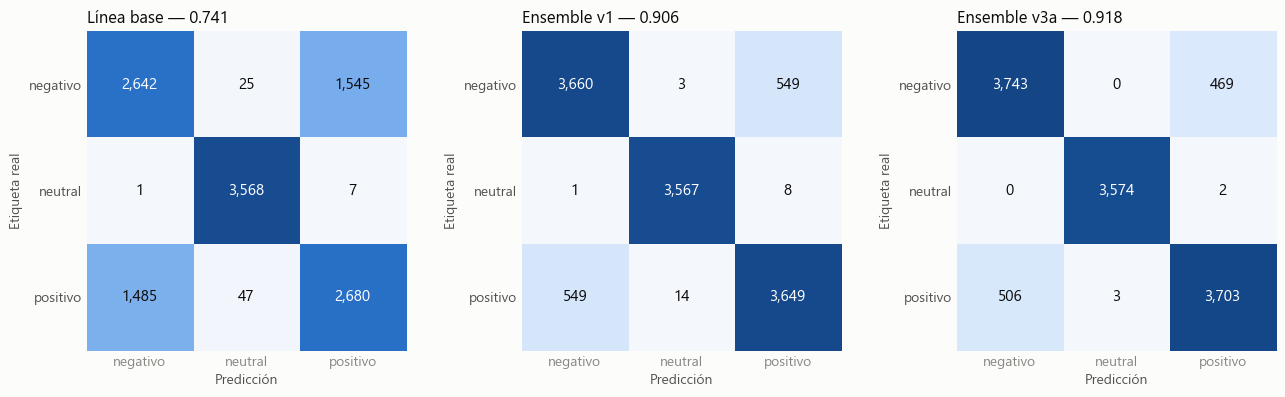

In [35]:
pred_v1_2p = CLASES[prob_ensemble(OOF, PESOS_V1_2P).argmax(1)]     # v1 con sus pesos de la sección 12
fig, axes = plt.subplots(1, 3, figsize=(13.2, 4))
graficar_confusion(axes[0], y, pred_base, f'Línea base — {accuracy_score(y, pred_base):.3f}')
graficar_confusion(axes[1], y, pred_v1_2p, f'Ensemble v1 — {accuracy_score(y, pred_v1_2p):.3f}')
graficar_confusion(axes[2], y, pred_v3a, f'Ensemble v3a — {accuracy_score(y, pred_v3a):.3f}')
plt.tight_layout(); plt.show()

**Interpretación**
- **Pesos finales: svc_pal_car 0.4, estructural 0.3, stk_nb6_anc 0.3** (el resto, 0). Con la media de las dos particiones, la rejilla elige los mismos pesos que con la partición 42 sola. Con la 2024 sola preferiría las regresiones logísticas al SVM, pero con los tres criterios `estructural` y `stk_nb6_anc` reciben 0.3 cada uno. La superficie es plana: las 10 mejores combinaciones están a menos de 0.05 puntos de accuracy media, y la segunda (*stacking 0.1 · lr_palabras 0.1 · svc_pal_car 0.2 · estructural 0.3 · stk_nb6_anc 0.3*) empata exactamente con la primera; en empate gana la primera combinación de la rejilla. El *stacking* v1 y las dos regresiones logísticas quedan con peso 0: lo que aportaban ya lo cubren el stacking NB-LR, que usa los mismos bloques, y el SVM, que usa la misma representación de palabras y caracteres que `lr_pal_car`.
- **Comparación en igualdad de condiciones.** Con el mismo procedimiento, el v1 elige *stacking 0.5, lr_palabras 0.5* y obtiene 0.9061 de accuracy anidada con la partición 42 (algo menos que el 0.9067 de la sección 8, que elegía los pesos solo con esa partición) y 0.9055 con la 2024. El v3a obtiene 0.9170 y 0.9134: **+1.09 y +0.79 puntos**, unas 131 reseñas más de 12 000 con la partición 42.
- **McNemar con aciertos anidados.** Con la partición 42, el v3a acierta 360 reseñas que el v1 falla y falla 229 que el v1 acierta (p = 7.5e-08); con la 2024, 338 frente a 243 (p = 9.3e-05). La mejora no es ruido.
- **Dónde se gana** (aciertos anidados, partición 42). El v3a recupera 109 errores netos **fuera** de las mixtas B, sobre todo en celdas deterministas: una opinión seguida de relleno, reseñas coherentes y mixtas A. Dentro de las mixtas B la mejora es pequeña (22 errores menos, de 53.0 % a 54.1 % de acierto) y compatible con el ruido. Fuera de B, el v3a acierta el 99.4 % de las reseñas, y el 94 % de los errores que quedan está en las mixtas B.

## 13. Robustez: aporte de cada componente y prueba de estrés del parser
Dos preguntas antes de quedarnos con el v3a:
1. **¿Cuánto aporta cada componente nuevo?** Comparamos cuatro conjuntos de componentes (v1, v1 + estructural, v1 + stk_nb6_anc y v3a), todos con el procedimiento de la sección 12, en las 2 particiones y con 3 semillas de la validación anidada (123, 7 y 99): 6 estimaciones por comparación. El **aporte marginal** de un componente es lo que pierde el v3a si se le quita. Las pruebas de McNemar usan los aciertos anidados, así que no favorecen al conjunto con más componentes.
2. **¿Qué pasa si el parser falla?** El componente estructural solo ve lo que el parser reconoce, y su inventario se escribió leyendo `train`. Ante giros que no están en el inventario (otros intensificadores u otros verbos copulativos), el parser puede no reconocer una opinión, y entonces el componente se equivoca con mucha confianza. Lo simulamos solo con `train`, en un escenario pesimista, y medimos cuánto se degrada cada ensemble.

In [36]:
# Aporte de cada componente nuevo: 4 conjuntos de componentes x 2 particiones x 3 semillas de la validación anidada.
# Todos eligen sus pesos con el mismo procedimiento (rejilla sobre la media de las dos particiones, validada de forma
# anidada) y el McNemar usa los aciertos anidados: cada reseña se predice con pesos elegidos sin mirarla.
VARIANTES = {'v1': NOMBRES_V1,
             'v1 + estructural': NOMBRES_V1 + ['estructural'],
             'v1 + stk_nb6_anc': NOMBRES_V1 + ['stk_nb6_anc'],
             'v3a': NOMBRES}
COMPARACIONES = {'v3a frente a v1': ('v3a', 'v1'),
                 'aporte de estructural (v3a frente a v1 + stk_nb6_anc)': ('v3a', 'v1 + stk_nb6_anc'),
                 'aporte de stk_nb6_anc (v3a frente a v1 + estructural)': ('v3a', 'v1 + estructural')}
t0 = time.time()
ANIDADO = {(v, s): seleccion_anidada(*rejilla(c), c, seed=s)[1] for v, c in VARIANTES.items() for s in SEMILLAS_ANIDADO}
assert (ANIDADO['v3a', SEED_ANIDADO] == ANIDADO_V3A).all() and (ANIDADO['v1', SEED_ANIDADO] == ANIDADO_V1).all()

filas_delta, filas_mc = [], []
for k, p in enumerate(PARTICIONES):
    for s in SEMILLAS_ANIDADO:
        acc = {v: ANIDADO[v, s][k].mean() for v in VARIANTES}
        filas_delta.append({'partición': p, 'semilla anidada': s, 'v1 (anidada)': acc['v1'],
                            **{f'{v} − v1': 100 * (acc[v] - acc['v1']) for v in list(VARIANTES)[1:]},
                            'aporte de estructural': 100 * (acc['v3a'] - acc['v1 + stk_nb6_anc']),
                            'aporte de stk_nb6_anc': 100 * (acc['v3a'] - acc['v1 + estructural'])})
        for nombre, (a, b) in COMPARACIONES.items():
            filas_mc.append({'partición': p, 'semilla anidada': s, 'comparación': nombre,
                             **mcnemar(ANIDADO[a, s][k], ANIDADO[b, s][k])})
robustez = pd.DataFrame(filas_delta).set_index(['partición', 'semilla anidada'])
COLUMNAS_DELTA = [c for c in robustez.columns if c != 'v1 (anidada)']
print(f'Accuracy anidada del v1 y diferencias en puntos porcentuales ({time.time() - t0:.0f} s):')
display(robustez.round({'v1 (anidada)': 4, **{c: 2 for c in COLUMNAS_DELTA}}))
resumen_robustez = robustez[COLUMNAS_DELTA].agg(['mean', 'min', 'max']).T.round(2)
resumen_robustez.columns = ['media', 'mínimo', 'máximo']
print('Resumen de las 6 estimaciones (2 particiones x 3 semillas), en puntos:')
display(resumen_robustez)

mc = pd.DataFrame(filas_mc)
mc['resultado'] = mc.gana.astype(str) + ' / ' + mc.pierde.astype(str) + '  (p = ' + mc.p.map('{:.1g}'.format) + ')'
print('McNemar con aciertos anidados: reseñas que el v3a acierta y la referencia falla / al revés (p-valor):')
display(mc.pivot_table(index=['partición', 'semilla anidada'], columns='comparación', values='resultado',
                       aggfunc='first')[list(COMPARACIONES)])

CORTO = {'v1 + estructural − v1': 'v1est', 'v1 + stk_nb6_anc − v1': 'v1stk', 'v3a − v1': 'v3a',
         'aporte de estructural': 'aporte_est', 'aporte de stk_nb6_anc': 'aporte_stk'}
for c, corto in CORTO.items():
    RESUMEN.update({f'rob_{corto}_media': robustez[c].mean(), f'rob_{corto}_min': robustez[c].min(),
                    f'rob_{corto}_max': robustez[c].max(),
                    **{f'rob_{corto}_{p}': robustez.loc[p, c].mean() for p in PARTICIONES}})
for nombre, corto in zip(COMPARACIONES, ['v3a', 'aporte_est', 'aporte_stk']):
    sub = mc[mc['comparación'] == nombre]
    RESUMEN.update({f'mc_{corto}_favorables': int((sub.gana > sub.pierde).sum()),
                    f'mc_{corto}_p_min': sub.p.min(), f'mc_{corto}_p_max': sub.p.max(),
                    **{f'mc_{corto}_p_max_{p}': sub[sub['partición'] == p].p.max() for p in PARTICIONES}})

Accuracy anidada del v1 y diferencias en puntos porcentuales (6 s):


v1 (anidada)  v1 + estructural − v1  v1 + stk_nb6_anc − v1  v3a − v1  aporte de estructural  aporte de stk_nb6_anc
partición semilla anidada                                                                                                                    
42        123                    0.9061                   0.85                   0.62      1.09                   0.47                   0.24
          7                      0.9048                   0.93                   0.79      1.11                   0.32                   0.18
          99                     0.9055                   0.77                   0.61      1.07                   0.46                   0.30
2024      123                    0.9055                   0.92                   0.35      0.79                   0.44                  -0.12
          7                      0.9060                   0.92                   0.44      0.77                   0.33                  -0.14
          99                     0.9062                   0.89                   0.40      0.69                   0.29                  -0.20

Resumen de las 6 estimaciones (2 particiones x 3 semillas), en puntos:


,media,mínimo,máximo
v1 + estructural − v1,0.88,0.77,0.93
v1 + stk_nb6_anc − v1,0.54,0.35,0.79
v3a − v1,0.92,0.69,1.11
aporte de estructural,0.38,0.29,0.47
aporte de stk_nb6_anc,0.04,-0.20,0.30


McNemar con aciertos anidados: reseñas que el v3a acierta y la referencia falla / al revés (p-valor):


comparación                        v3a frente a v1 aporte de estructural (v3a frente a v1 + stk_nb6_anc) aporte de stk_nb6_anc (v3a frente a v1 + estructural)
partición semilla anidada                                                                                                                                     
42        7                 362 / 229  (p = 5e-08)                                 190 / 152  (p = 0.05)                                  208 / 187  (p = 0.3)
          99                352 / 224  (p = 1e-07)                                195 / 140  (p = 0.003)                                 190 / 154  (p = 0.06)
          123               360 / 229  (p = 8e-08)                                184 / 128  (p = 0.002)                                  213 / 184  (p = 0.2)
2024      7                333 / 240  (p = 0.0001)                                 174 / 134  (p = 0.03)                                  181 / 198  (p = 0.4)
          99               308 / 225  (p = 0.0004)                                 156 / 121  (p = 0.04)                                  156 / 180  (p = 0.2)
          123               338 / 243  (p = 9e-05)                                158 / 105  (p = 0.001)                                  192 / 207  (p = 0.5)

**Lectura**
- **El componente estructural es el que más aporta.** Añadido al v1 gana +0.88 puntos de media (entre +0.77 y +0.93), y su aporte marginal dentro del v3a es de +0.38 (entre +0.29 y +0.47), con McNemar favorable en las 6 estimaciones (p ≤ 0.045).
- **El stacking NB-LR aporta por sí solo, pero casi nada cuando ya está el estructural.** Añadido al v1 gana +0.54 puntos de media: +0.67 con la partición 42, donde se eligió su configuración, y +0.40 con la 2024. Dentro del v3a su aporte marginal es de +0.04 de media (+0.24 con la partición 42 y −0.16 con la 2024), con McNemar favorable solo en 3 de las 6 estimaciones y nunca significativo (p entre 0.06 y 0.48). Es decir, **no podemos atribuir a `stk_nb6_anc` ninguna mejora del v3a en validación cruzada**: los dos componentes nuevos corrigen en buena parte los mismos errores. Lo mantenemos por el resultado de la prueba de estrés que sigue.
- **v3a frente al v1:** +0.92 puntos de media (entre +0.69 y +1.11), con McNemar favorable en 6 de 6 estimaciones y p ≤ 3.7e-04. La cifra media de la partición 42 (+1.09) es más alta que la de la 2024 (+0.75), coherente con que los componentes se diseñaron mirando la partición 42.

In [37]:
# Prueba de estrés del parser (solo con train). En cada fold se reajusta el componente estructural (idéntico al de su
# OOF) y en el fold de validación se simula que el parser no reconoce una opinión escrita con giros que no están en
# su inventario: (a) en el 1.7 % de las reseñas pierde la ÚLTIMA opinión de una mixta cuyas dos últimas opiniones son
# de cópula + adjetivo con signos opuestos (justo la opinión que decide la etiqueta) y (b) en otro 1.1 % no reconoce la
# única opinión de la reseña. Los pesos se eligen con las OOF intactas, como al desplegar el modelo, y se aplican a
# las OOF perturbadas.
FALLO_ULTIMA, FALLO_TODAS = 0.017, 0.011       # fracción de cada fold de validación con cada tipo de fallo


def estres_un_fold(entrenamiento, validacion, semilla):
    y_codificada = np.searchsorted(CLASES, y)                       # igual que cross_val_predict
    modelo = modelo_estructural().fit(X[entrenamiento], y_codificada[entrenamiento])
    estructura, hgb = modelo.named_steps['estructura'], modelo.named_steps['hgb']
    analisis = estructura.analizar(X[validacion])

    def probabilidades(lista_analisis):
        return hgb.predict_proba(pd.DataFrame([rasgos_estructurales(p, estructura.signo)
                                               for p in lista_analisis]).astype(float))

    rng = np.random.RandomState(semilla)
    inversion = [j for j, p in enumerate(analisis) if len(p['opiniones']) >= 2
                 and all(es_adjetival(o) for o in p['opiniones'][-2:])
                 and estructura.signo(p['opiniones'][-1]['clave']) != estructura.signo(p['opiniones'][-2]['clave'])]
    una_opinion = [j for j, p in enumerate(analisis) if len(p['opiniones']) == 1]
    sel_ultima = rng.choice(inversion, int(round(FALLO_ULTIMA * len(validacion))), replace=False)
    sel_todas = rng.choice(una_opinion, int(round(FALLO_TODAS * len(validacion))), replace=False)
    perturbado = list(analisis)
    for j in sel_ultima:
        perturbado[j] = dict(analisis[j], opiniones=analisis[j]['opiniones'][:-1])
    for j in sel_todas:
        perturbado[j] = dict(analisis[j], opiniones=[])
    discrepancias = sum(v != signo_semantico(k) for k, v in estructura.lexico_.items())
    return (validacion, probabilidades(analisis), probabilidades(perturbado),
            validacion[np.concatenate([sel_ultima, sel_todas]).astype(int)], discrepancias, len(estructura.lexico_))


t0 = time.time()
P_INTACTA, P_ESTRES, PERTURBADAS, polaridad_folds = {}, {}, {}, []
for p, cv_p in [(SEED, CV), (SEED_2, CV_2)]:
    P_INTACTA[p], P_ESTRES[p] = np.zeros((len(y), len(CLASES))), np.zeros((len(y), len(CLASES)))
    PERTURBADAS[p] = np.zeros(len(y), dtype=bool)
    tareas = (joblib.delayed(estres_un_fold)(a, b, p + k) for k, (a, b) in enumerate(cv_p.split(X, y)))
    for va, P_i, P_e, idx, discrepancias, n_claves in joblib.Parallel(n_jobs=N_JOBS)(tareas):
        P_INTACTA[p][va], P_ESTRES[p][va] = P_i, P_e
        PERTURBADAS[p][idx] = True
        polaridad_folds.append({'partición': p, 'claves': n_claves, 'distintas de la semántica': discrepancias})
    print(f'Partición {p}: max |OOF reconstruida − OOF del componente| = '
          f'{np.abs(P_INTACTA[p] - OOF_PARTICION[p]["estructural"]).max():.1e} | reseñas perturbadas: '
          f'{PERTURBADAS[p].sum()} ({PERTURBADAS[p].mean():.1%})')

filas = []
for v in ['v1 + estructural', 'v3a']:
    comps = VARIANTES[v]
    W_v, AC_v = rejilla(comps)
    AC_estres = [evaluar_rejilla({**OOF_PARTICION[p], 'estructural': P_ESTRES[p]}, comps)[1] for p in PARTICIONES]
    for s in SEMILLAS_ANIDADO:
        _, estresado = seleccion_anidada(W_v, AC_v, comps, seed=s, aplicar=AC_estres)
        for k, p in enumerate(PARTICIONES):
            m, base = PERTURBADAS[p], ANIDADO['v1', s][k].mean()
            filas.append({'conjunto': v, 'partición': p, 'semilla anidada': s,
                          'ganancia, parser intacto': 100 * (ANIDADO[v, s][k].mean() - base),
                          'ganancia, parser perturbado': 100 * (estresado[k].mean() - base),
                          'acc. perturbadas, intacto': ANIDADO[v, s][k][m].mean(),
                          'acc. perturbadas, perturbado': estresado[k][m].mean(),
                          'acc. perturbadas, v1': ANIDADO['v1', s][k][m].mean()})
estres = pd.DataFrame(filas)
COLS_GANANCIA = ['ganancia, parser intacto', 'ganancia, parser perturbado']
print(f'({time.time() - t0:.0f} s) Ganancia sobre el v1 en puntos (selección anidada; media y mínimo de las 6 '
      'estimaciones, 2 particiones x 3 semillas):')
display(estres.groupby('conjunto', sort=False)[COLS_GANANCIA].agg(['mean', 'min']).round(2))

acc_est = {c: np.mean([accuracy_score(y[PERTURBADAS[p]], CLASES[P[p][PERTURBADAS[p]].argmax(1)]) for p in PARTICIONES])
           for c, P in [('parser intacto', P_INTACTA), ('parser perturbado', P_ESTRES)]}
acc_perturbadas = pd.DataFrame({
    'parser intacto': {'estructural (solo)': acc_est['parser intacto'], 'v1 (no usa el parser)': estres['acc. perturbadas, v1'].mean(),
                       **estres.groupby('conjunto', sort=False)['acc. perturbadas, intacto'].mean().to_dict()},
    'parser perturbado': {'estructural (solo)': acc_est['parser perturbado'], 'v1 (no usa el parser)': estres['acc. perturbadas, v1'].mean(),
                          **estres.groupby('conjunto', sort=False)['acc. perturbadas, perturbado'].mean().to_dict()}})
print('Accuracy en las reseñas perturbadas (media de las dos particiones y de las tres semillas):')
display(acc_perturbadas.round(3))
pol = pd.DataFrame(polaridad_folds)
print(f'Polaridad aprendida en los {len(pol)} folds: {pol["distintas de la semántica"].sum()} claves distintas de la '
      f'polaridad semántica del inventario, de {pol.claves.sum()}.')

for v, corto in [('v1 + estructural', 'v1est'), ('v3a', 'v3a')]:
    sub = estres[estres.conjunto == v]
    RESUMEN.update({f'estres_{corto}_intacto': sub[COLS_GANANCIA[0]].mean(), f'estres_{corto}_media': sub[COLS_GANANCIA[1]].mean(),
                    f'estres_{corto}_min': sub[COLS_GANANCIA[1]].min(),
                    f'acc_pert_{corto}_intacto': sub['acc. perturbadas, intacto'].mean(),
                    f'acc_pert_{corto}_perturbado': sub['acc. perturbadas, perturbado'].mean()})
RESUMEN['estres_aporte_stk'] = RESUMEN['estres_v3a_media'] - RESUMEN['estres_v1est_media']
RESUMEN.update(acc_pert_est_intacto=acc_est['parser intacto'], acc_pert_est_perturbado=acc_est['parser perturbado'],
               acc_pert_v1=estres['acc. perturbadas, v1'].mean(),
               estres_pct_perturbadas=float(np.mean([PERTURBADAS[p].mean() for p in PARTICIONES])),
               polaridad_discrepancias=int(pol['distintas de la semántica'].sum()), polaridad_claves=int(pol.claves.sum()))

Partición 42: max |OOF reconstruida − OOF del componente| = 0.0e+00 | reseñas perturbadas: 335 (2.8%)


Partición 2024: max |OOF reconstruida − OOF del componente| = 0.0e+00 | reseñas perturbadas: 335 (2.8%)


(80 s) Ganancia sobre el v1 en puntos (selección anidada; media y mínimo de las 6 estimaciones, 2 particiones x 3 semillas):


ganancia, parser intacto       ganancia, parser perturbado      
                                     mean   min                        mean   min
conjunto                                                                         
v1 + estructural                     0.88  0.77                        0.56  0.50
v3a                                  0.92  0.69                        0.79  0.53

Accuracy en las reseñas perturbadas (media de las dos particiones y de las tres semillas):


,parser intacto,parser perturbado
estructural (solo),0.990,0.007
v1 (no usa el parser),0.983,0.983
v1 + estructural,0.994,0.880
v3a,0.997,0.949


Polaridad aprendida en los 10 folds: 0 claves distintas de la polaridad semántica del inventario, de 1132.


**Lectura de la prueba de estrés.** En el escenario simulado el parser falla en el 2.8 % de las reseñas de validación. En esas reseñas el componente estructural pasa de acertar el 99.0 % a acertar el 0.7 %: cuando pierde la opinión decisiva se equivoca con mucha confianza. El v1, que no usa el parser, acierta el 98.3 %. Los ensembles amortiguan el daño de forma muy distinta:
- **v1 + estructural** baja al 88.0 % en esas reseñas, y su ganancia sobre el v1 cae de +0.88 a +0.56 puntos de media (mínimo +0.50);
- **v3a** se queda en el 94.9 %, y su ganancia solo cae de +0.92 a +0.79 (mínimo +0.53).

Con el parser fallando, `stk_nb6_anc` vale +0.22 puntos dentro del v3a: es un segundo modelo, de n-gramas, que también se fija en las opiniones y contradice al estructural cuando este pierde la opinión decisiva. Por eso **nunca usamos el componente estructural solo con el v1**, aunque en validación cruzada limpia rinda casi igual que el v3a, y por eso la ganancia del CV debe leerse como una cota optimista para datos con giros nuevos. Además, en los 10 folds la polaridad aprendida coincide con la semántica en todas las claves (0 distintas de 1132), como se adelantó en la sección 10.

**Sesgo de diseño: cuánto puede inflar la ganancia.** El inventario del parser y los rasgos del componente estructural se escribieron mirando todo `train`, y las variantes de los dos componentes se eligieron mirando la partición 42 (la versión final del estructural, también la 2024), así que la validación cruzada no es del todo limpia. Una auditoría de los componentes, con scripts fuera de este notebook y la misma metodología anidada, midió cuánto cambia la ganancia de **v1 + estructural** sobre el v1 al quitar las decisiones tomadas mirando los datos. Son medias de 6 estimaciones con las OOF de desarrollo, en las que el componente tal como está gana +0.84 (+0.88 en este notebook):
- sin las entradas del inventario añadidas a partir de errores OOF: +0.78;
- descartando dentro de cada fold las entradas del inventario con menos de 5 o de 10 reseñas de soporte: +0.65 / +0.70;
- sin los 35 rasgos de interacción diseñados mirando tablas por celda: +0.65;
- la peor de todas las variantes: +0.42.

El sesgo existe y es del orden de 0.1–0.25 puntos, pero no explica la mejora. Para el stacking NB-LR, la misma auditoría estimó su aporte como componente extra del v1 en ≈ +0.4 puntos, frente a los +0.86 de la configuración elegida con la partición 42 (sección 11). **Estimación prudente:** la ganancia del v3a sobre el v1 en validación cruzada está entre +0.6 y +0.9 puntos, y en Kaggle puede ser algo menor si las reseñas de evaluación usan giros que el parser no reconoce (en la prueba de estrés: +0.79).

## 14. Resumen de iteraciones y experimentos que no funcionaron

In [38]:
filas = [('0. Línea base (TF-IDF texto completo + LR)', RESUMEN['acc_linea_base'], np.nan, np.nan, np.nan, '—')]
for i, (n, texto) in enumerate([('lr_palabras', 'Bloques + palabras + LR'),
                                 ('lr_pal_car', 'Bloques + palabras y caracteres + LR'),
                                 ('svc_pal_car', 'Bloques + palabras y caracteres + SVM'),
                                 ('stacking', 'Stacking por bloques + HGB')], start=1):
    filas.append((f'{i}. {texto} ({n})', RESUMEN[f'acc_{n}'], np.nan, RESUMEN[f'acc_{n}_{SEED_2}'], np.nan, '—'))
filas += [('5. Ensemble v1 (4 componentes)', RESUMEN['v1_2p_oof'], RESUMEN['v1_2p_anidado'], RESUMEN['v1_2p_oof_2024'],
           RESUMEN['v1_2p_anidado_2024'], '0.90111'),
          ('6. Componente estructural (parser + HGB)', RESUMEN['acc_estructural'], np.nan,
           RESUMEN[f'acc_estructural_{SEED_2}'], np.nan, '—'),
          ('7. Stacking NB-LR con bloques anclados (stk_nb6_anc)', RESUMEN['acc_stk_nb6_anc'], np.nan,
           RESUMEN[f'acc_stk_nb6_anc_{SEED_2}'], np.nan, '—'),
          ('8. Ensemble v3a (6 componentes)', RESUMEN['v3a_oof'], RESUMEN['v3a_anidado'], RESUMEN['v3a_oof_2024'],
           RESUMEN['v3a_anidado_2024'], 'por enviar')]
iteraciones = pd.DataFrame(filas, columns=['iteración', f'oof_{SEED}', f'anidada_{SEED}', f'oof_{SEED_2}',
                                           f'anidada_{SEED_2}', 'kaggle_público']).set_index('iteración')
print('oof: accuracy OOF (ensembles: con sus pesos finales) | anidada: selección de pesos validada de forma anidada. '
      'Los dos ensembles eligen sus pesos con las dos particiones (sección 12).')
display(iteraciones.round(4))

oof: accuracy OOF (ensembles: con sus pesos finales) | anidada: selección de pesos validada de forma anidada. Los dos ensembles eligen sus pesos con las dos particiones (sección 12).


,oof_42,anidada_42,oof_2024,anidada_2024,kaggle_público
iteración,,,,,
0. Línea base (TF-IDF texto completo + LR),0.7408,NaN,NaN,NaN,—
1. Bloques + palabras + LR (lr_palabras),0.8951,NaN,0.8939,NaN,—
2. Bloques + palabras y caracteres + LR (lr_pal_car),0.8981,NaN,0.8962,NaN,—
3. Bloques + palabras y caracteres + SVM (svc_pal_car),0.8998,NaN,0.8998,NaN,—
4. Stacking por bloques + HGB (stacking),0.9012,NaN,0.9004,NaN,—
5. Ensemble v1 (4 componentes),0.9063,0.9061,0.9068,0.9055,0.90111
6. Componente estructural (parser + HGB),0.9075,NaN,0.9096,NaN,—
7. Stacking NB-LR con bloques anclados (stk_nb6_anc),0.9112,NaN,0.9094,NaN,—
8. Ensemble v3a (6 componentes),0.9183,0.9170,0.9150,0.9134,por enviar


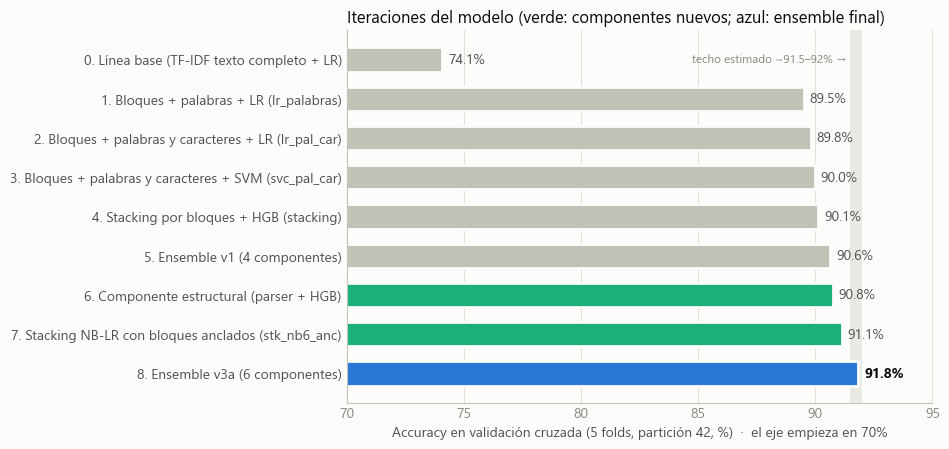

In [39]:
orden = list(iteraciones.index)
vals = iteraciones[f'oof_{SEED}'].values
colores = [AZUL if n.startswith('8.') else (AQUA if n.startswith(('6.', '7.')) else GRIS) for n in orden]
fig, ax = plt.subplots(figsize=(9.6, 4.6))
ypos = np.arange(len(orden))[::-1]
ax.barh(ypos, 100 * vals, height=0.62, color=colores, edgecolor=SUPERFICIE, linewidth=2)
for yy, v, n in zip(ypos, vals, orden):
    final = n.startswith('8.')
    ax.text(100 * v + 0.25, yy, f'{100 * v:.1f}%', va='center', fontsize=10, color=TINTA if final else TINTA2,
            fontweight='bold' if final else 'normal')
ax.set_yticks(ypos, orden)
ax.set_xlim(70, 95); ax.xaxis.grid(True); ax.set_axisbelow(True); ax.tick_params(length=0)
ax.axvspan(91.5, 92.0, color=REJILLA, alpha=0.7, zorder=0, linewidth=0)
ax.text(91.3, ypos[0], 'techo estimado ~91.5–92% →', color=TENUE, fontsize=8.5, ha='right', va='center')
ax.set_xlabel('Accuracy en validación cruzada (5 folds, partición 42, %)  ·  el eje empieza en 70%')
ax.set_title('Iteraciones del modelo (verde: componentes nuevos; azul: ensemble final)', color=TINTA)
plt.tight_layout(); plt.show()

### Experimentos que no funcionaron
Cifras de la fase de exploración (scripts de desarrollo, partición 42, pesos elegidos solo con esa partición). "pts" = cambio en puntos porcentuales de la accuracy **anidada** del ensemble respecto al ensemble v1 al añadir el componente.

| Experimento | Resultado | Conclusión |
|---|---|---|
| Otros clasificadores sobre los bloques de palabras | LinearSVC 0.896, Ridge 0.895, SGD 0.888, MultinomialNB 0.871, ComplementNB 0.837, kNN coseno 0.779, ExtraTrees 0.783 (0.827 con chi²), RandomForest 0.743 (0.777 con chi²), HGB sobre chi² k=3000 0.888, árbol de decisión 0.652 | Los lineales sobre n-gramas dominan; los árboles no aprovechan miles de rasgos dispersos |
| Reducción de dimensión LSA (300 componentes) + HGB / + LR | 0.767 / 0.776 | Se pierde la información de palabras concretas |
| Preprocesamiento (sonda: LR con bloques = 0.8951) | mantener tildes 0.8877; corregir typos 0.8953; stemming 0.8950; typos + stemming 0.8956; quitar stopwords 0.8911; marcar negación 0.8928; números → token 0.8952; TF-IDF binario 0.8937; sin IDF 0.8878; norma L1 0.868 | Nada supera el ruido (±0.1); quitar stopwords o conservar tildes empeora |
| Eliminar reseñas con etiqueta sospechosa (*confident learning*, umbral 0.15 / 0.30 / 0.45) | 0.891 / 0.890 / 0.885 | El ruido de las mixtas B es intrínseco: no se limpia quitando ejemplos |
| Búsqueda aleatoria de hiperparámetros (87 configuraciones) de los modelos lineales | ±0.1 | Los hiperparámetros del v1 ya eran óptimos |
| Meta-HGB del stacking ajustado | stacking 0.898 → 0.9025, pero ensemble sin mejora (anidado 0.904–0.905) | La mejora del componente no llega al ensemble |
| Stacking v2 con ~15 rasgos estructurales simples (antes de descubrir las dos familias) | ensemble anidado 0.905 | Rasgos demasiado gruesos |
| Meta-modelo de segundo nivel (LR / HGB) sobre las OOF + conector + tipo de cierre | 0.900–0.906 | No supera al voto ponderado |
| Árboles (HGB sobre chi²) como miembro extra del ensemble | peso óptimo 0 | No aporta diversidad útil |
| kNN / paráfrasis entre reseñas | similitud coseno mediana con el vecino más cercano 0.27; 1-NN acierta 50 % en las celdas aleatorias | No hay reseñas "gemelas" que delaten la etiqueta |
| Rasgos aspecto × polaridad en mixtas con conector aditivo | ~53 % | La etiqueta no depende de qué aspecto se elogia o se critica |
| Búsqueda de señal en las mixtas B (orden, intensidad, posición, concordancia, identidad del cierre, TF-IDF dentro del grupo; con permutaciones y corrección de Benjamini-Hochberg) | 0.47–0.52 (p = 0.22–0.96) | Las mixtas B son ruido irreducible |
| NB-LR plano (palabras) como componente extra | 0.900 individual (el mejor lineal), pero −0.20 pts (peso 0) | NB-LR solo ayuda **dentro** del stacking por bloques |
| Tokens conjuntados con el tipo de conector o la posición de la oración | −0.08 a −0.27 pts | Sobreajusta |
| Pares de palabras entre cláusulas (hashing) | −0.13 a −0.27 pts | Sin señal |
| Rangos de n-gramas distintos por bloque | −0.07 pts | Los rangos actuales ya son adecuados |
| Stacking NB-LR con n-gramas de caracteres | +0.24 pts, frente a +0.86 de la configuración elegida, solo con palabras (≈ +0.4 sin sesgo de selección, sección 11), y 7 veces más lento | Los caracteres no ayudan dentro del NB-LR |
| Control: el mismo stacking con LR TF-IDF por bloque en lugar de NB-LR | 0.898 (igual que el stacking v1 en esa ejecución; con NB-LR, 0.908), −0.27 pts | La ganancia viene de la representación NB |
| Auto-entrenamiento de un clasificador de cláusulas a partir de la etiqueta del documento | colapsó (0.69 en reseñas de una sola opinión) | En las mixtas, la etiqueta del documento no sirve para etiquetar cláusulas |
| Componente alternativo `est_lr`: clasificador de cláusulas + ~80 rasgos + LR | componente 0.913; +0.52 pts (42) / +0.32 (2024); con los dos componentes de este modelo: +1.14 (42) pero +0.62 (2024) | No se incluyó: es redundante con `estructural` y la combinación de 7 componentes no se sostiene con la partición 2024 |

## 15. Modelo final: entrenamiento con todo `train` y guardado
El modelo final es un `VotingClassifier` de voto suave con los pesos elegidos en la sección 12 (accuracy OOF media de las dos particiones). Solo incluye los componentes con peso mayor que cero, y se entrena con las 12 000 reseñas de `train`. Todo el preprocesamiento (normalización, bloques, parser, detector, vectorizadores) está dentro de los pipelines, así que el objeto guardado recibe **texto crudo**. El *cross-fitting* interno de `BloquesAnclados` y del stacking se repite al entrenar, exactamente como en la validación.

In [40]:
miembros = [(n, FABRICAS[n]()) for n in NOMBRES if PESOS[n] > 0]
modelo_final = VotingClassifier(miembros, voting='soft', weights=[PESOS[n] for n, _ in miembros], n_jobs=N_JOBS)

t0 = time.time()
modelo_final.fit(X, y)
RESUMEN['segundos_entrenamiento_final'] = time.time() - t0
RESUMEN['pesos_finales'] = ', '.join(f'{n} {PESOS[n]:.1f}' for n, _ in miembros)
print(f'Entrenado en {RESUMEN["segundos_entrenamiento_final"]:.0f} s | miembros {[n for n, _ in miembros]} | '
      f'pesos {modelo_final.weights}')

joblib.dump(modelo_final, 'modelo_v3a.joblib', compress=3)
RESUMEN['mb_joblib'] = os.path.getsize('modelo_v3a.joblib') / 2 ** 20
print(f'Modelo guardado en modelo_v3a.joblib ({RESUMEN["mb_joblib"]:.1f} MB)')

Entrenado en 55 s | miembros ['svc_pal_car', 'estructural', 'stk_nb6_anc'] | pesos [0.4, 0.3, 0.3]


Modelo guardado en modelo_v3a.joblib (9.8 MB)


## 16. Predicción de `eval.csv` y archivo de envío
Es la primera vez que el notebook lee `eval.csv`; antes no se usó para nada. Comprobamos además que el modelo **recargado desde disco** produce exactamente las mismas predicciones.

Para cargar `modelo_v3a.joblib` en otra sesión hay que ejecutar antes las celdas que definen las funciones y clases que el pipeline referencia: la configuración (sección 1), `normalizar` (sección 3), las listas de conectores y `oraciones` (sección 5), `Bloques` (sección 6), los vectorizadores y las listas de bloques (sección 7), el corrector, el inventario y el parser (sección 9), `Estructura` (sección 10) y `NBLR` / `BloquesAnclados` (sección 11). Lo comprobamos en una sesión nueva, fuera de este notebook: con esas 11 celdas de código, el modelo recargado reproduce las 3 000 predicciones.

In [41]:
assert 'evaluacion' not in globals(), 'eval.csv no debe haberse leído antes de este punto'
evaluacion = pd.read_csv(f'{DATA_DIR}/eval.csv')
muestra = pd.read_csv(f'{DATA_DIR}/sample_submission.csv')

t0 = time.time()
pred_eval = modelo_final.predict(evaluacion.text.values)
print(f'Predicción de {len(evaluacion)} reseñas en {time.time() - t0:.0f} s')

modelo_cargado = joblib.load('modelo_v3a.joblib')
pred_cargado = modelo_cargado.predict(evaluacion.text.values)
assert (pred_cargado == pred_eval).all()
print('El modelo recargado desde modelo_v3a.joblib reproduce las 3 000 predicciones:', (pred_cargado == pred_eval).all())
modelo_cargado.predict(['La batería es excelente, pero la cámara resultó decepcionante.',
                        'La cámara resultó decepcionante. Aun así, la batería es excelente.',
                        'Me llegó en tres días. Trae garantía de un año y usa dos pilas AA.'])

Predicción de 3000 reseñas en 7 s


El modelo recargado desde modelo_v3a.joblib reproduce las 3 000 predicciones: True


array(['negativo', 'positivo', 'neutral'], dtype=object)

In [42]:
submission = pd.DataFrame({'id': evaluacion.id, 'answer': pred_eval})
submission.to_csv('submission_v3a.csv', index=False)

leida = pd.read_csv('submission_v3a.csv')
assert list(leida.columns) == list(muestra.columns) == ['id', 'answer']
assert len(leida) == len(muestra) == 3000
assert (leida.id.values == muestra.id.values).all()
assert leida.answer.isin(CLASES).all() and leida.answer.notna().all()
print('submission_v3a.csv validado: columnas id,answer | 3000 filas | mismos ids y orden que sample_submission | '
      'valores en {' + ', '.join(CLASES) + '}')

distribucion = pd.DataFrame({'n_predicho_eval': leida.answer.value_counts(),
                             'proporción_eval': leida.answer.value_counts(normalize=True),
                             'proporción_train': train.label.value_counts(normalize=True)}).loc[CLASES]
display(distribucion.round(3))
RESUMEN['distribucion'] = ', '.join(f'{c} {int(n)}' for c, n in distribucion.n_predicho_eval.items())
for c in CLASES:
    RESUMEN[f'pct_{c}_eval'] = distribucion.loc[c, 'proporción_eval']

if os.path.exists('submission.csv'):
    anterior = pd.read_csv('submission.csv')
    assert (anterior.id.values == leida.id.values).all()
    cambia = anterior.answer.values != leida.answer.values
    RESUMEN['cambios_vs_v1'] = int(cambia.sum())
    RESUMEN['cambios_pos_neg'] = int((cambia & (anterior.answer.values != 'neutral') & (leida.answer.values != 'neutral')).sum())
    RESUMEN['pct_neutral_v1'] = (anterior.answer == 'neutral').mean()
    print(f'Predicciones que cambian respecto a submission.csv (ensemble v1, Kaggle 0.90111): {cambia.sum()} de '
          f'{len(cambia)} ({cambia.mean():.1%})')
    display(pd.crosstab(anterior.answer.rename('v1 (submission.csv)'), leida.answer.rename('v3a'), margins=True))

submission_v3a.csv validado: columnas id,answer | 3000 filas | mismos ids y orden que sample_submission | valores en {negativo, neutral, positivo}


,n_predicho_eval,proporción_eval,proporción_train
negativo,1093,0.364,0.351
neutral,829,0.276,0.298
positivo,1078,0.359,0.351


Predicciones que cambian respecto a submission.csv (ensemble v1, Kaggle 0.90111): 173 de 3000 (5.8%)


v3a,negativo,neutral,positivo,All
v1 (submission.csv),,,,
negativo,1008,1,78,1087
neutral,2,822,3,827
positivo,83,6,997,1086
All,1093,829,1078,3000


La distribución predicha en `eval` (negativo 36.4 %, neutral 27.6 %, positivo 35.9 %) tiene algo menos de neutrales que `train`, igual que el envío v1 (27.6 % de neutrales). Respecto al envío anterior cambian 173 de 3 000 predicciones (5.8 %). De esos cambios, 161 son entre `positivo` y `negativo`: cambios de polaridad, típicos de las reseñas mixtas.

## 17. Cumplimiento de las reglas del proyecto
La celda siguiente **comprueba** (no solo afirma) las reglas que se pueden verificar con código:
1. Ninguna librería prohibida (redes neuronales, embeddings, transformers, boosting externo) está cargada en la sesión.
2. Todos los estimadores dentro del modelo final, recorridos de forma recursiva, son clases de **scikit-learn** o transformadores propios definidos en este notebook (reglas, regex, léxicos). Ninguno es una red neuronal.
3. `eval.csv` se leyó por primera vez en la sección 16 (lo garantiza la aserción de esa celda), después de entrenar y guardar el modelo. Nada se ajustó con esos datos: ni vocabularios, ni IDF, ni pseudo-etiquetas, ni selección de rasgos, ni pesos del ensemble.

In [43]:
PROHIBIDAS = ['torch', 'tensorflow', 'keras', 'jax', 'transformers', 'sentence_transformers', 'gensim', 'spacy',
              'stanza', 'fasttext', 'flair', 'xgboost', 'lightgbm', 'catboost']
cargadas = [m for m in PROHIBIDAS if m in sys.modules]


def estimadores_internos(obj, vistos=None):
    # Recorre recursivamente el modelo ajustado y devuelve todos los estimadores que contiene
    vistos = set() if vistos is None else vistos
    if id(obj) in vistos:
        return
    vistos.add(id(obj))
    if isinstance(obj, BaseEstimator):
        yield obj
    if isinstance(obj, dict):
        hijos = list(obj.values())
    elif isinstance(obj, (list, tuple)):
        hijos = list(obj)
    elif hasattr(obj, '__dict__') and type(obj).__module__.startswith(('sklearn', '__main__')):
        hijos = list(vars(obj).values())
    else:
        return
    for h in hijos:
        if isinstance(h, (BaseEstimator, dict, list, tuple)) or (hasattr(h, '__dict__') and type(h).__module__.startswith(('sklearn', '__main__'))):
            yield from estimadores_internos(h, vistos)


clases_usadas = sorted({f'{type(e).__module__}.{type(e).__name__}' for e in estimadores_internos(modelo_cargado)})
ajenas = [c for c in clases_usadas if not c.startswith(('sklearn.', '__main__.'))]
neuronales = [c for c in clases_usadas if 'neural_network' in c or 'MLP' in c]
print('Clases de estimadores dentro del modelo final:')
for c in clases_usadas:
    print('   ', c)
assert not cargadas, f'librerías prohibidas cargadas: {cargadas}'
assert not ajenas and not neuronales, (ajenas, neuronales)
print('\nOK: solo scikit-learn + transformadores propios; ninguna librería prohibida cargada;',
      'eval.csv solo se usó para predecir.')

Clases de estimadores dentro del modelo final:


    __main__.Bloques
    __main__.BloquesAnclados
    __main__.Estructura
    __main__.NBLR
    sklearn.calibration.CalibratedClassifierCV
    sklearn.calibration._SigmoidCalibration
    sklearn.compose._column_transformer.ColumnTransformer
    sklearn.ensemble._hist_gradient_boosting.binning._BinMapper
    sklearn.ensemble._hist_gradient_boosting.gradient_boosting.HistGradientBoostingClassifier
    sklearn.ensemble._stacking.StackingClassifier
    sklearn.ensemble._voting.VotingClassifier
    sklearn.feature_extraction.text.CountVectorizer
    sklearn.feature_extraction.text.TfidfTransformer
    sklearn.feature_extraction.text.TfidfVectorizer
    sklearn.linear_model._logistic.LogisticRegression
    sklearn.pipeline.Pipeline
    sklearn.preprocessing._label.LabelEncoder
    sklearn.svm._classes.LinearSVC

OK: solo scikit-learn + transformadores propios; ninguna librería prohibida cargada; eval.csv solo se usó para predecir.


| Regla | Cómo se cumple |
|---|---|
| Solo ML clásico de scikit-learn | Regresión logística, SVM lineal, HistGradientBoosting, `StackingClassifier` y `VotingClassifier`; NB-LR es una regresión logística sobre rasgos binarios escalados (lineal) |
| Representaciones clásicas | TF-IDF / bolsa de palabras binaria de palabras (1-2) y de caracteres (2-5) por bloque; rasgos estructurales hechos con reglas, regex y léxicos escritos a mano o aprendidos de `train` dentro de cada fold |
| Sin redes neuronales, embeddings, transformers ni xgboost / lightgbm / catboost | Verificado arriba (librerías cargadas y clases del modelo final) |
| `eval.csv` solo para predecir | Se lee en la sección 16, después de entrenar; la aserción `'evaluacion' not in globals()` lo garantiza |
| Evaluación sin fuga | Todo lo aprendido (corrector, polaridades, vocabularios, razones NB, detector, meta-modelos) se ajusta dentro de cada fold de `cross_val_predict`; los pesos del ensemble se validan de forma anidada |

## 18. Conclusiones y limitaciones
**Conclusiones**
- **De 0.741 a 0.917 (anidado, partición 42) sin salir del ML clásico.** Ningún salto vino de cambiar de clasificador: todos vinieron de **analizar los errores** y cambiar la **representación**. Primero vectorizamos por separado los fragmentos del texto según los conectores. Después entendimos cómo están construidas las reseñas.
- **Dos familias de plantillas.** En las mixtas A (cópula + adjetivo) la última opinión decide la etiqueta casi siempre. En las mixtas B (frases hechas, el 17 % de `train`) la etiqueta es prácticamente aleatoria. Este hallazgo explica el techo de ~0.915–0.92 y nos dice dónde no vale la pena insistir.
- **El componente estructural es el que aporta.** El parser codifica las reglas deterministas de la plantilla A y corrige errores en celdas deterministas. El v3a mejora al v1 en +0.92 puntos de accuracy anidada de media (entre +0.69 y +1.11 en 2 particiones × 3 semillas), con McNemar significativo en todas las estimaciones. El aporte marginal del estructural es de +0.38 puntos; el del stacking NB-LR, de +0.04 (no significativo). El stacking NB-LR se queda en el modelo porque lo hace bastante más robusto a los fallos del parser (sección 13).
- **Proceso.** Cada componente se evaluó con las mismas particiones y sin fuga (todo se ajusta dentro del fold, con *cross-fitting* donde hace falta). Los pesos se eligieron con dos particiones y se validaron de forma anidada, y los aportes se midieron con McNemar sobre aciertos anidados. El modelo final queda con tres componentes: *svc_pal_car 0.4, estructural 0.3, stk_nb6_anc 0.3*.

**Limitaciones (honestas)**
- **Ruido irreducible.** Las 2042 mixtas B (~17 %) se aciertan al ~54 %, y en ellas está el 94 % de los errores restantes. Ningún método que solo vea el texto puede superar ~0.915–0.92 en validación cruzada, y en Kaggle cabe esperar algo parecido.
- **Sesgo de diseño.** El inventario del parser, sus rasgos de interacción y las listas de conectores se escribieron **a mano mirando todo `train`**, incluidas tasas por etiqueta y errores OOF de la partición 42. Además, las variantes de los dos componentes se eligieron mirando la partición 42 (la versión final del estructural, también la 2024). La validación cruzada no anida ese diseño. Según la auditoría resumida en la sección 13, el sesgo infla la ganancia del orden de 0.1–0.25 puntos: una estimación prudente de la mejora del v3a sobre el v1 es de **+0.6 a +0.9 puntos**.
- **Dependencia del inventario y de las plantillas.** El componente estructural solo entiende las frases de su inventario, y con giros que no aparecen en `train` se equivoca con confianza. La prueba de estrés muestra que el v3a lo amortigua: su ganancia pasa de +0.92 a +0.79 puntos con el parser fallando en el 2.8 % de las reseñas. Aun así, la ganancia real en Kaggle puede ser menor que la del CV, y en reseñas reales, con vocabulario libre, el aporte del componente se reduciría mucho. Es también la limitación de fondo de la bolsa de palabras: el orden lo inyectamos "a mano" con reglas, en lugar de aprenderlo de la secuencia como haría un modelo secuencial (Parte 2).
- **El stacking NB-LR podría simplificarse.** Sus bloques anclados no superan de forma consistente al mismo stacking sin anclar (`stk_nb6`, los 6 bloques de la sección 6). Según la auditoría, ese stacking más simple aporta algo más sobre el estructural (+0.18 puntos en ambas particiones). No lo cambiamos para no volver a elegir componentes mirando las mismas particiones; queda como mejora futura.
- **Sensibilidad numérica.** Los dos *stacking* cambian algunas décimas según el número de hilos de BLAS y sus semillas internas. El notebook fija ambos para ser reproducible, pero en otra máquina los componentes pueden variar ±0.1–0.3 puntos.
- **Mejora pequeña frente al ruido de Kaggle.** ~0.9 puntos son ~27 reseñas de 3 000. El *leaderboard* público usa ~900 reseñas (error estándar ≈ 1 punto), así que la mejora podría no verse con claridad en el público; el privado (~2 100 reseñas) es más fiable.
- **Costo.** El modelo final entrena en ~55 s (el stacking v1, el componente más lento según la tabla de la sección 12, queda con peso 0) y ocupa 9.8 MB. Lo costoso es la evaluación: el notebook completo, con dos particiones, el análisis de robustez y la prueba de estrés, tarda ~21 minutos.

### Resumen numérico
Todas las cifras clave calculadas en este notebook. El texto de las secciones anteriores cita estos valores.

In [44]:
import json

RESUMEN['minutos_totales'] = (time.time() - T_INICIO) / 60
RESUMEN['minutos_entrenamiento'] = RESUMEN['segundos_entrenamiento_final'] / 60
RESUMEN['delta_reseñas'] = RESUMEN['delta_anidado_pts'] / 100 * len(y)
if 'cambios_vs_v1' in RESUMEN:
    RESUMEN['pct_cambios'] = RESUMEN['cambios_vs_v1'] / len(evaluacion)


def _a_python(v):
    return int(v) if isinstance(v, np.integer) else (float(v) if isinstance(v, float) else v)


display(pd.Series({k: (f'{v:.2e}' if k.startswith('mcnemar_p') else (round(v, 4) if isinstance(v, float) else v))
                   for k, v in RESUMEN.items()}, dtype=object).to_frame('valor'))
print('RESUMEN (JSON):', json.dumps({k: _a_python(v) for k, v in RESUMEN.items()}, ensure_ascii=False))

,valor
acc_linea_base,0.7408
acc_stacking,0.9012
acc_lr_palabras,0.8951
acc_lr_pal_car,0.8981
acc_svc_pal_car,0.8998
...,...
pct_neutral_v1,0.2757
minutos_totales,20.9282
minutos_entrenamiento,0.9152
delta_reseñas,131.0


RESUMEN (JSON): {"acc_linea_base": 0.7408333333333333, "acc_stacking": 0.9011666666666667, "acc_lr_palabras": 0.8950833333333333, "acc_lr_pal_car": 0.8980833333333333, "acc_svc_pal_car": 0.89975, "v1_oof": 0.9069166666666667, "v1_anidado": 0.9066666666666666, "A_ultima_fin_opinion": 0.9983108108108109, "n_A_fin_opinion": 4144, "A_ultima": 0.992271662763466, "n_A": 4270, "B_ultima": 0.5137120470127327, "n_B": 2042, "pct_B": 0.17016666666666666, "B_v1": 0.5313418217433888, "pct_errores_v1_en_B": 0.8567591763652641, "acc_estructural": 0.9075, "acc_stk_nb6_anc": 0.9111666666666667, "acc_stacking_2024": 0.9004166666666666, "acc_lr_palabras_2024": 0.8939166666666667, "acc_lr_pal_car_2024": 0.89625, "acc_svc_pal_car_2024": 0.89975, "acc_estructural_2024": 0.9095833333333333, "acc_stk_nb6_anc_2024": 0.9094166666666667, "pesos": "stacking 0.0, lr_palabras 0.0, lr_pal_car 0.0, svc_pal_car 0.4, estructural 0.3, stk_nb6_anc 0.3", "pesos_v1_2p": "stacking 0.5, lr_palabras 0.5", "v1_2p_oof": 0.90633